# 🍽️ Project 3: AI Demand Forecasting — Week 1 & 2
## Time-Series EDA + Feature Engineering for Restaurant Sales

**Domain:** Food & Restaurant Services  
**Dataset:** `restaurant_sales.csv` — Synthetic POS data (Jan 2023 – Dec 2024)  

---

## 📌 Dataset Overview

| Property | Value |
|----------|-------|
| **Date Range** | Jan 1, 2023 → Dec 31, 2024 (2 full years) |
| **Total Records** | 5,848 rows |
| **Granularity** | Daily sales per menu item |
| **Menu Items** | Biryani, Butter Chicken, Dal Makhani, Gulab Jamun, Mango Lassi, Masala Dosa, Naan, Paneer Tikka |
| **Key Columns** | `date`, `day_of_week`, `month`, `year`, `is_weekend`, `is_holiday`, `menu_item`, `units_sold`, `unit_price`, `revenue` |


---
## Install & Import Libraries

Install & Import Libraries

All libraries used in this notebook come **pre-installed on Google Colab**.  
The pip install cell below is a safety net — it will do nothing if libraries are already present.

| Library | Purpose |
|---|---|
| `pandas` | Data manipulation and time-series aggregation |
| `numpy` | Numerical operations |
| `matplotlib` | Base plotting library |
| `seaborn` | Statistical visualizations and heatmaps |
| `statsmodels` | `seasonal_decompose`, `plot_acf`, `plot_pacf` |

In [9]:
!pip install pandas numpy matplotlib seaborn statsmodels --quiet

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


---
##Load & Clean the Dataset

### Key cleaning steps:
- Convert `date` column to proper `datetime` format
- Set `date` as the index for time-based operations
- Check for missing dates, nulls, and duplicates
- Create **daily aggregates** (total revenue & units sold across all menu items per day)

## Upload & Load Dataset

Run this cell — a **Choose Files** button will appear.  
Upload `restaurant_sales.csv` from your local machine.

> **Note:** The file is loaded into Colab's temporary session memory.  
> It will need to be re-uploaded if the runtime is restarted.

In [11]:
# ── Upload your dataset ──────────────────────────────────────────────────────
# Run this cell → click 'Choose Files' → upload restaurant_sales.csv
from google.colab import files
import io

print('👇 Click "Choose Files" and upload restaurant_sales.csv')
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))

print(f'\n✅ Loaded: {filename}')
print(f'   Shape  : {df.shape}')
print(f'   Columns: {df.columns.tolist()}')
df.head()


👇 Click "Choose Files" and upload restaurant_sales.csv


Saving restaurant_sales.csv to restaurant_sales.csv

✅ Loaded: restaurant_sales.csv
   Shape  : (5848, 10)
   Columns: ['date', 'day_of_week', 'month', 'year', 'is_weekend', 'is_holiday', 'menu_item', 'units_sold', 'unit_price', 'revenue']


,date,day_of_week,month,year,is_weekend,is_holiday,menu_item,units_sold,unit_price,revenue
0,2023-01-01,Sunday,1,2023,1,0,Biryani,160,350,56000
1,2023-01-01,Sunday,1,2023,1,0,Butter Chicken,114,320,36480
2,2023-01-01,Sunday,1,2023,1,0,Dal Makhani,79,220,17380
3,2023-01-01,Sunday,1,2023,1,0,Gulab Jamun,72,80,5760
4,2023-01-01,Sunday,1,2023,1,0,Mango Lassi,81,90,7290


## Data Cleaning & Validation

Before any analysis, we validate the dataset for three critical issues:

- **dtype correctness** — `date` must be `datetime64`, not string
- **null values** — any missing values would corrupt aggregations and lag features
- **date continuity** — gaps in the time series would break rolling windows and lag calculations

> A clean, continuous time series with zero nulls is the foundation of reliable forecasting.

In [12]:
# ─── Step 2.1: Convert date column to datetime ────────────────────────────────
# pd.to_datetime() ensures Python treats this as a real date, not a string
df['date'] = pd.to_datetime(df['date'])

print("Data types after conversion:")
print(df.dtypes)

# ─── Step 2.2: Check for nulls ────────────────────────────────────────────────
print(f"\nNull values per column:")
print(df.isnull().sum())

# ─── Step 2.3: Unique menu items ──────────────────────────────────────────────
print(f"\nMenu items ({df['menu_item'].nunique()} total):")
print(df['menu_item'].unique())

# ─── Step 2.4: Date range ─────────────────────────────────────────────────────
print(f"\nDate range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Total unique dates: {df['date'].nunique()}")

Data types after conversion:
date           datetime64[ns]
day_of_week            object
month                   int64
year                    int64
is_weekend              int64
is_holiday              int64
menu_item              object
units_sold              int64
unit_price              int64
revenue                 int64
dtype: object

Null values per column:
date           0
day_of_week    0
month          0
year           0
is_weekend     0
is_holiday     0
menu_item      0
units_sold     0
unit_price     0
revenue        0
dtype: int64

Menu items (8 total):
['Biryani' 'Butter Chicken' 'Dal Makhani' 'Gulab Jamun' 'Mango Lassi'
 'Masala Dosa' 'Naan' 'Paneer Tikka']

Date range: 2023-01-01 to 2024-12-31
Total unique dates: 731


### Create Daily Aggregated DataFrame

The raw dataset has **8 rows per day** — one per menu item.  
For overall trend analysis we need a single daily total, so we `groupby('date')` and `sum()`.

We also extract `month_name`, `quarter`, and `week` (ISO week number) for later seasonality plots.

In [13]:
# ─── Step 2.5: Create daily aggregated DataFrame ──────────────────────────────
#
# Our raw data has 8 rows per day (one per menu item).
# For overall trend analysis, we need TOTAL daily sales.
# We group by date and sum revenue + units_sold.
#
daily = df.groupby('date').agg(
    total_revenue  = ('revenue',    'sum'),
    total_units    = ('units_sold', 'sum'),
    is_weekend     = ('is_weekend', 'first'),   # Same for all items on a given date
    is_holiday     = ('is_holiday', 'first'),
    day_of_week    = ('day_of_week','first'),
    month          = ('month',      'first'),
    year           = ('year',       'first')
).reset_index()

# Add month name and quarter for easier plotting
daily['month_name'] = daily['date'].dt.month_name()
daily['quarter']    = daily['date'].dt.quarter
daily['week']       = daily['date'].dt.isocalendar().week.astype(int)

# Check for missing dates (gaps in the time series)
expected = pd.date_range(start=daily['date'].min(), end=daily['date'].max(), freq='D')
missing  = expected.difference(daily['date'])
print(f"Total daily records: {len(daily)}")
print(f"Missing dates: {len(missing)}")
print(f"\nFirst few rows of daily aggregate:")
daily.head()

Total daily records: 731
Missing dates: 0

First few rows of daily aggregate:


,date,total_revenue,total_units,is_weekend,is_holiday,day_of_week,month,year,month_name,quarter,week
0,2023-01-01,166150,846,1,0,Sunday,1,2023,January,1,52
1,2023-01-02,88180,450,0,0,Monday,1,2023,January,1,1
2,2023-01-03,108010,581,0,0,Tuesday,1,2023,January,1,1
3,2023-01-04,109370,575,0,0,Wednesday,1,2023,January,1,1
4,2023-01-05,113420,572,0,0,Thursday,1,2023,January,1,1


---
## Basic Data Exploration


## Basic Descriptive Statistics

We use `.describe()` on the daily aggregates to get a feel for the scale and spread of the data  
before investing time in visualisations.

**What to look for:**
- Large gap between mean and max → outlier days (holidays, festivals)
- Year-wise averages increasing → confirms long-term growth trend

In [14]:
print("=" * 55)
print("SUMMARY STATISTICS — Daily Aggregated Data")
print("=" * 55)
print(daily[['total_revenue', 'total_units']].describe().round(2))

print("\n--- Year-wise Average ---")
print(daily.groupby('year')[['total_revenue','total_units']].mean().round(2))

SUMMARY STATISTICS — Daily Aggregated Data
       total_revenue  total_units
count         731.00       731.00
mean       163560.81       845.56
std         48281.01       249.20
min         83790.00       427.00
25%        127230.00       659.50
50%        156630.00       809.00
75%        190010.00       975.50
max        461190.00      2495.00

--- Year-wise Average ---
      total_revenue  total_units
year                            
2023      148654.44       765.91
2024      178426.45       924.99


### Revenue & Units Distribution

Histograms reveal the **shape of the distribution** of daily totals.  
A right-skewed distribution (long tail on right) is expected — most days have moderate sales,  
but holiday/festive days create high-value outliers that pull the mean above the median.

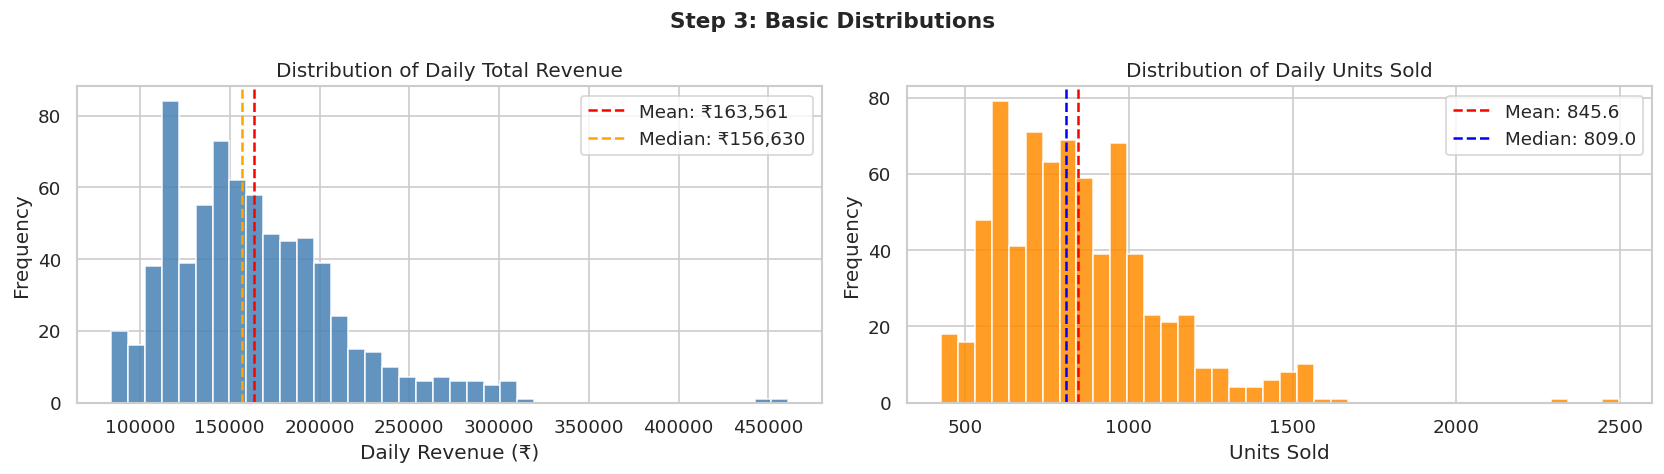

In [15]:
# ─── Distribution plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Revenue distribution
axes[0].hist(daily['total_revenue'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(daily['total_revenue'].mean(),   color='red',    linestyle='--', label=f"Mean: ₹{daily['total_revenue'].mean():,.0f}")
axes[0].axvline(daily['total_revenue'].median(), color='orange', linestyle='--', label=f"Median: ₹{daily['total_revenue'].median():,.0f}")
axes[0].set_title('Distribution of Daily Total Revenue')
axes[0].set_xlabel('Daily Revenue (₹)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Units sold distribution
axes[1].hist(daily['total_units'], bins=40, color='darkorange', edgecolor='white', alpha=0.85)
axes[1].axvline(daily['total_units'].mean(),   color='red',    linestyle='--', label=f"Mean: {daily['total_units'].mean():.1f}")
axes[1].axvline(daily['total_units'].median(), color='blue',   linestyle='--', label=f"Median: {daily['total_units'].median():.1f}")
axes[1].set_title('Distribution of Daily Units Sold')
axes[1].set_xlabel('Units Sold')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Step 3: Basic Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
##Overall Sales Trend

### What are rolling averages?
- **7-day rolling mean**: Average of last 7 days — smooths out day-to-day noise
- **30-day rolling mean**: Average of last 30 days — reveals the long-term trend

An **upward sloping** 30-day line means the business is growing over time.

##Overall Revenue Trend

### What are rolling averages?

| Rolling Window | Purpose |
|---|---|
| **7-day** | Smooths daily noise, shows intra-week pattern |
| **30-day** | Reveals the underlying long-term business trend |

An **upward-sloping 30-day line** confirms the business is growing over time — this  
growth must be captured by a trend feature (`day_number` or `months_elapsed`) in the model.

The two year-bands (blue = 2023, green = 2024) make YoY comparison visually immediate.

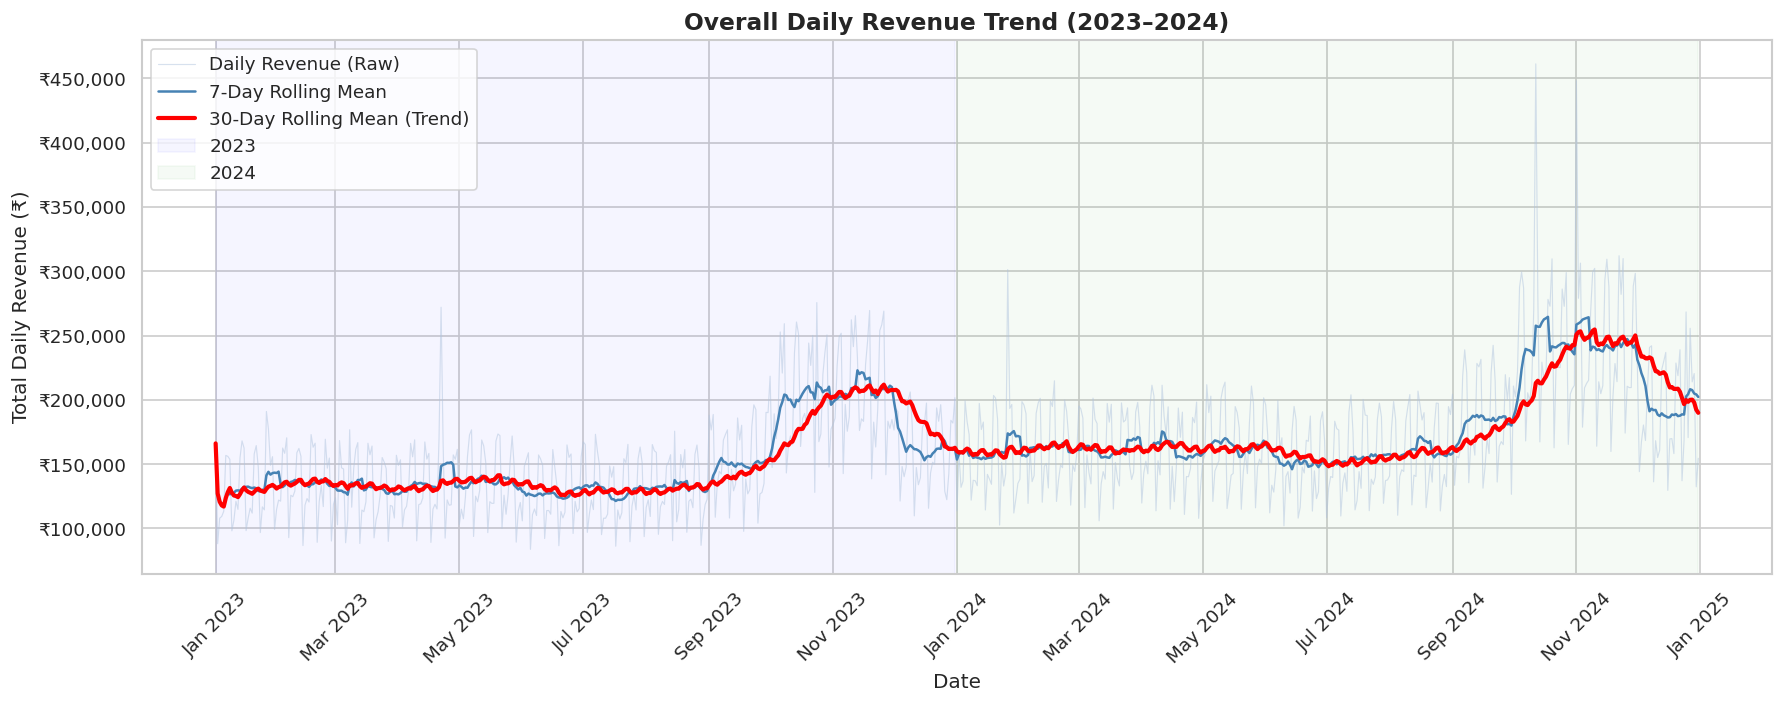

Average daily revenue — 2023: ₹148,654
Average daily revenue — 2024: ₹178,426
Year-on-year change: +20.0%


In [16]:
# ─── Compute rolling averages ─────────────────────────────────────────────────
daily = daily.sort_values('date').reset_index(drop=True)
daily['rolling_7d']  = daily['total_revenue'].rolling(window=7,  min_periods=1).mean()
daily['rolling_30d'] = daily['total_revenue'].rolling(window=30, min_periods=1).mean()

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(daily['date'], daily['total_revenue'],
        color='lightsteelblue', linewidth=0.7, alpha=0.5, label='Daily Revenue (Raw)')
ax.plot(daily['date'], daily['rolling_7d'],
        color='steelblue', linewidth=1.5, label='7-Day Rolling Mean')
ax.plot(daily['date'], daily['rolling_30d'],
        color='red', linewidth=2.5, label='30-Day Rolling Mean (Trend)')

# Shade the two years differently for easy comparison
ax.axvspan(pd.Timestamp('2023-01-01'), pd.Timestamp('2023-12-31'),
           alpha=0.04, color='blue', label='2023')
ax.axvspan(pd.Timestamp('2024-01-01'), pd.Timestamp('2024-12-31'),
           alpha=0.04, color='green', label='2024')

ax.set_title('Overall Daily Revenue Trend (2023–2024)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Total Daily Revenue (₹)')
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Year-on-year change
avg_2023 = daily[daily['year']==2023]['total_revenue'].mean()
avg_2024 = daily[daily['year']==2024]['total_revenue'].mean()
print(f"Average daily revenue — 2023: ₹{avg_2023:,.0f}")
print(f"Average daily revenue — 2024: ₹{avg_2024:,.0f}")
print(f"Year-on-year change: {((avg_2024 - avg_2023)/avg_2023)*100:+.1f}%")

---
##Weekly Seasonality Analysis

**Weekly seasonality** = the same sales pattern repeats every 7 days.
Restaurants typically see higher footfall on weekends (Fri–Sun) and lower on weekdays.

Our dataset has an `is_weekend` column — we'll verify this and measure the exact magnitude of the weekend effect.

## Weekly Seasonality Analysis

**Weekly seasonality** = the same pattern repeats every 7 days.  
Restaurants consistently see higher footfall on **Friday–Sunday** and a dip on **Monday**.

We use two complementary plots:
- **Bar chart** — shows the average revenue per day
- **Box plot** — shows the spread and variance per day (are weekends consistently high, or just occasionally?)

> `is_weekend` and `day_of_week` will both be features in the Week 3 model.

/tmp/ipykernel_5559/3161746523.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(daily_data_per_day, labels=day_order, patch_artist=True)


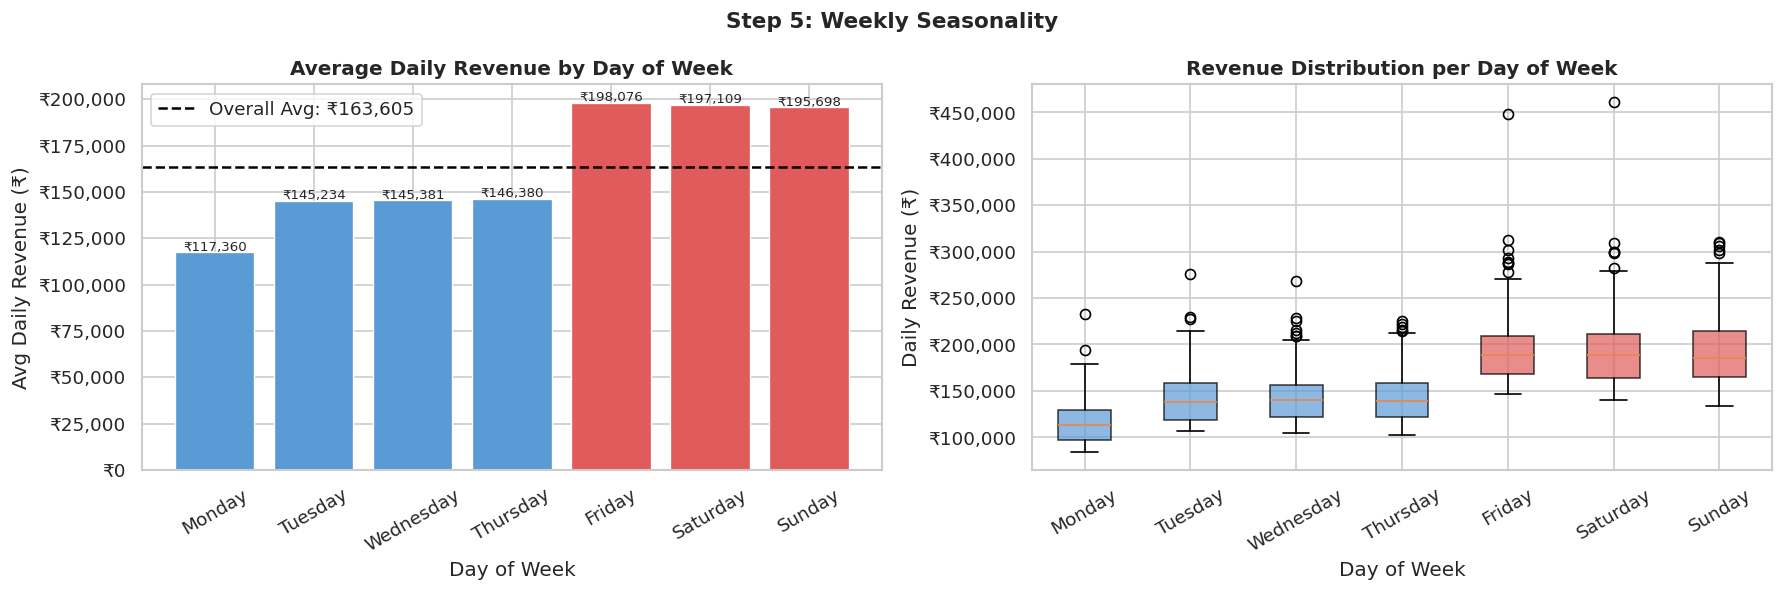

Weekend average: ₹196,400
Weekday average: ₹150,412
Weekend premium: +30.6%


In [17]:
# ─── Average revenue by day of week ───────────────────────────────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekly_avg = daily.groupby('day_of_week')['total_revenue'].mean().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
colors = ['#e05c5c' if d in ['Friday','Saturday','Sunday'] else '#5b9bd5' for d in day_order]
bars = axes[0].bar(day_order, weekly_avg, color=colors, edgecolor='white', linewidth=0.8)
axes[0].axhline(weekly_avg.mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Overall Avg: ₹{weekly_avg.mean():,.0f}')
axes[0].set_title('Average Daily Revenue by Day of Week', fontweight='bold')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Avg Daily Revenue (₹)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for bar, val in zip(bars, weekly_avg):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
                 f'₹{val:,.0f}', ha='center', fontsize=8)

# Box plot — shows spread, not just average
daily_data_per_day = [daily[daily['day_of_week'] == d]['total_revenue'].values for d in day_order]
bp = axes[1].boxplot(daily_data_per_day, labels=day_order, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Revenue Distribution per Day of Week', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Daily Revenue (₹)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('Step 5: Weekly Seasonality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Weekend premium
wknd = daily[daily['is_weekend']==1]['total_revenue'].mean()
wkdy = daily[daily['is_weekend']==0]['total_revenue'].mean()
print(f"Weekend average: ₹{wknd:,.0f}")
print(f"Weekday average: ₹{wkdy:,.0f}")
print(f"Weekend premium: +{((wknd-wkdy)/wkdy)*100:.1f}%")

### Weekly Revenue Heatmap

Each **row** = one ISO calendar week. Each **column** = a day of the week.  
Colour intensity shows how busy that specific day-week slot was.

**What to look for:**
- Consistently dark Fri/Sat/Sun columns → reliable weekly pattern
- Isolated bright rows → outlier weeks (festive, holiday events)
- Consistent light Mon/Tue columns → confirmed Monday demand dip

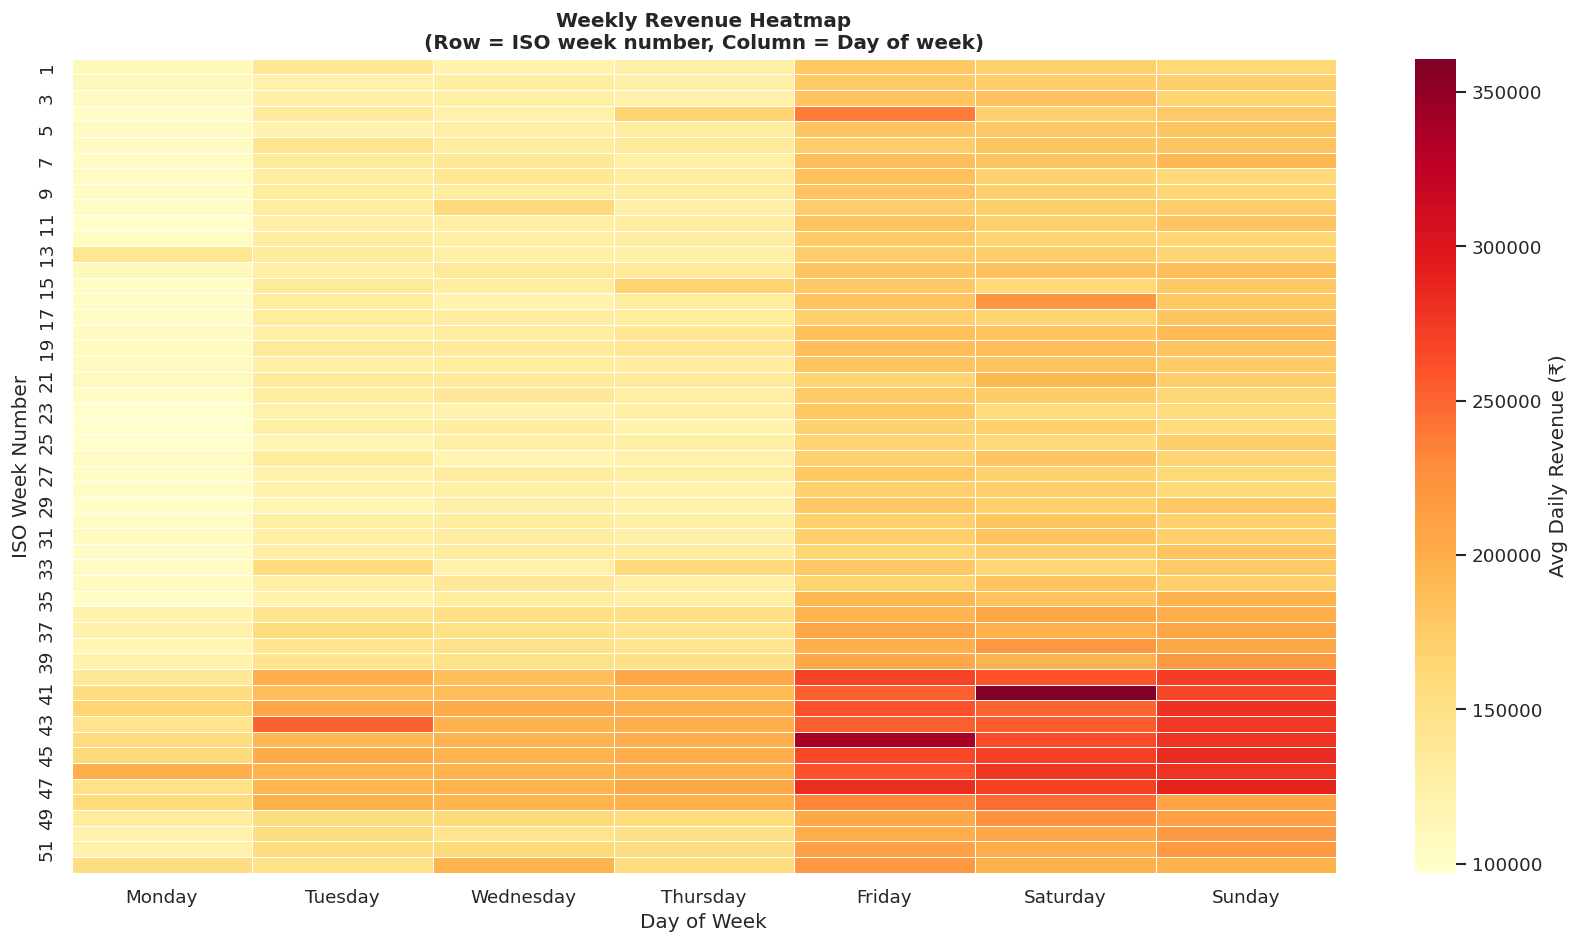


💡 Interpretation:
  - Dark orange/red columns on Friday–Sunday = consistent weekend surge.
  - Light yellow on Monday–Tuesday = weaker weekday demand.
  - 'is_weekend' flag in our dataset will be a powerful model feature.



In [18]:
# ─── Weekly heatmap: week number × day of week ────────────────────────────────
# Each row = one ISO week. Each column = a day of the week.
# Color intensity shows how busy that particular day-week combination was.

pivot = daily.pivot_table(index='week', columns='day_of_week',
                          values='total_revenue', aggfunc='mean')
pivot = pivot.reindex(columns=day_order)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Avg Daily Revenue (₹)'},
            fmt='.0f')
plt.title('Weekly Revenue Heatmap\n(Row = ISO week number, Column = Day of week)',
          fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('ISO Week Number')
plt.tight_layout()
plt.show()

print("""
💡 Interpretation:
  - Dark orange/red columns on Friday–Sunday = consistent weekend surge.
  - Light yellow on Monday–Tuesday = weaker weekday demand.
  - 'is_weekend' flag in our dataset will be a powerful model feature.
""")

---
## Monthly Seasonality Analysis

Monthly seasonality captures **which months are consistently busier** across both years.
This is driven by factors like festivals, school holidays, weather, and tourist seasons.

## Monthly Seasonality Analysis

Monthly seasonality captures **which months are consistently busier** across both years.  
Drivers include Indian festivals, school holidays, weather, and tourist seasons.

We plot two views:
1. **Combined average** — 2023 and 2024 averaged together to reveal stable patterns
2. **YoY comparison** — 2023 vs 2024 side-by-side to confirm patterns repeat (not coincidental)

> October and November are highlighted — the Indian festive season (Navratri, Dussehra, Diwali)  
> is the strongest demand signal in the dataset. `is_festive_month` should be engineered.

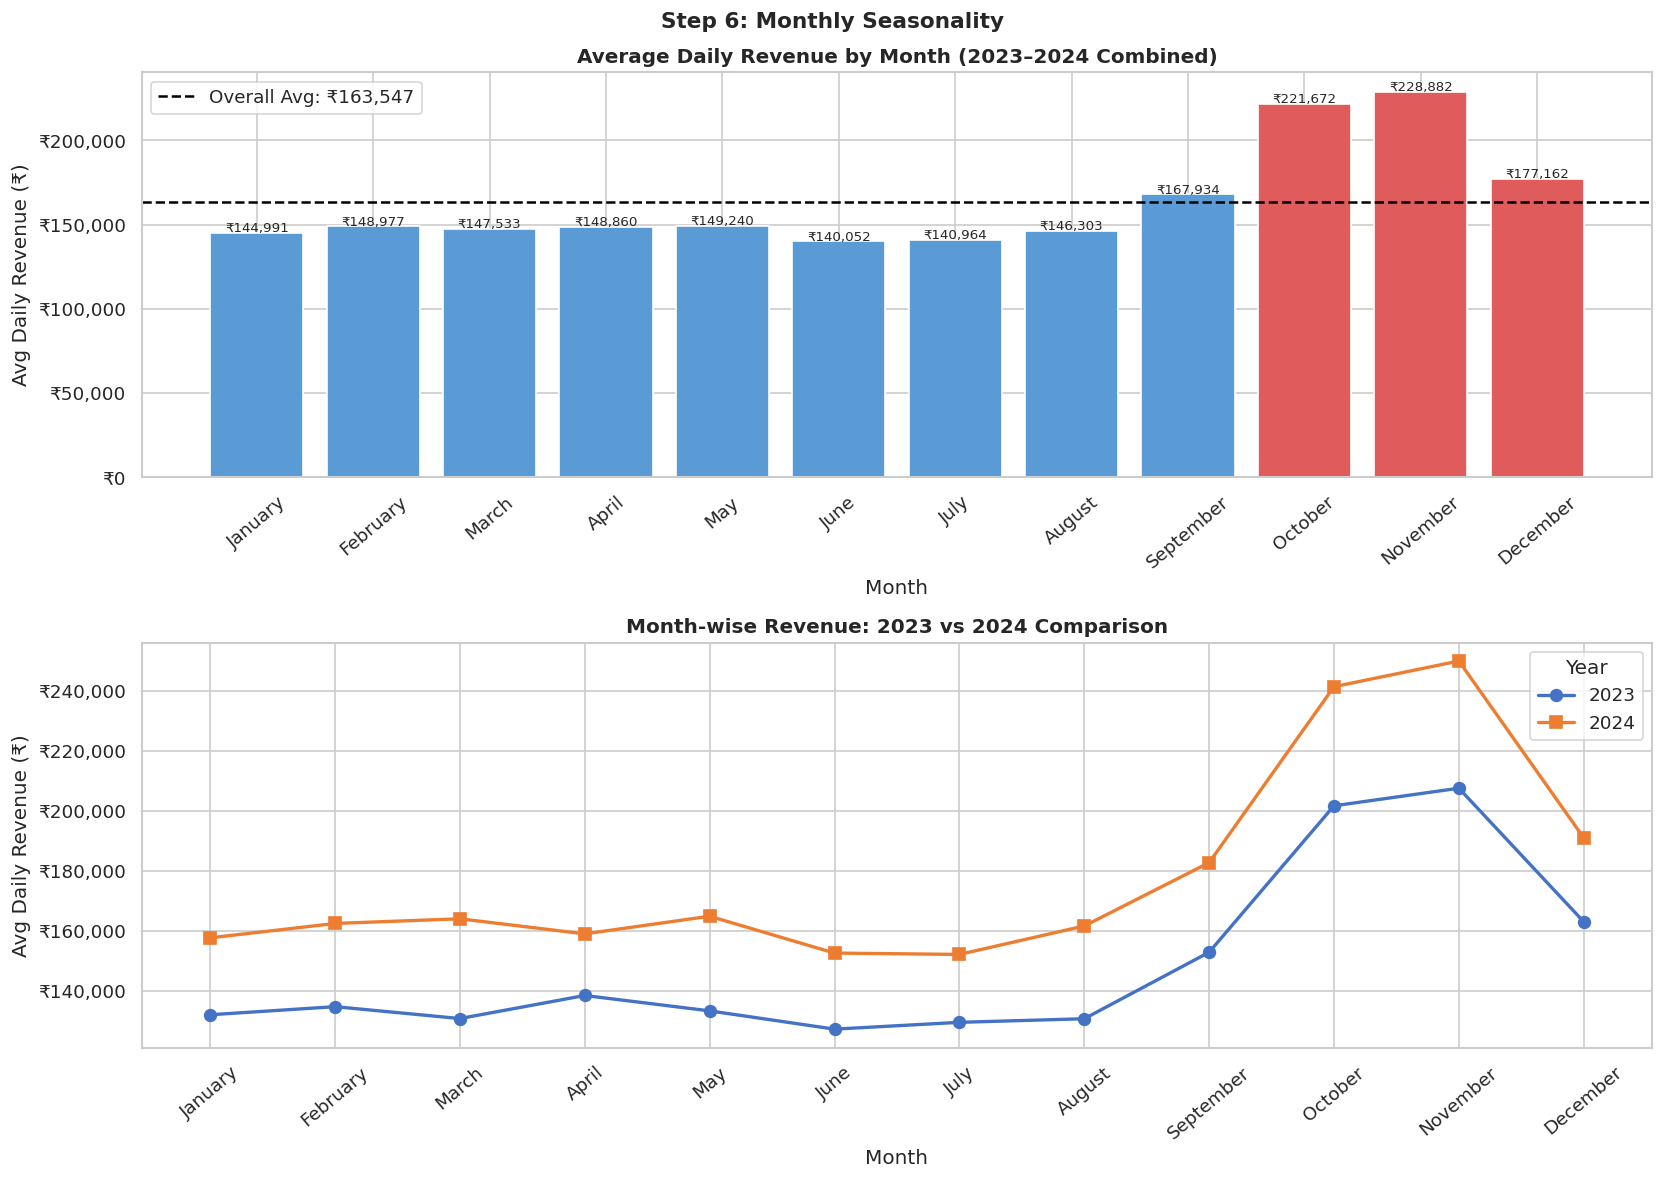

Peak months (top 3): ['November', 'October', 'December']


In [19]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_avg  = daily.groupby('month_name')['total_revenue'].mean().reindex(month_order)
monthly_year = daily.groupby(['year','month_name'])['total_revenue'].mean().unstack(0).reindex(month_order)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ─── Top: overall monthly average ────────────────────────────────────────────
top3_months = monthly_avg.nlargest(3).index.tolist()
bar_colors  = ['#e05c5c' if m in top3_months else '#5b9bd5' for m in month_order]
axes[0].bar(month_order, monthly_avg, color=bar_colors, edgecolor='white')
axes[0].axhline(monthly_avg.mean(), color='black', linestyle='--', linewidth=1.5,
                label=f'Overall Avg: ₹{monthly_avg.mean():,.0f}')
axes[0].set_title('Average Daily Revenue by Month (2023–2024 Combined)', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Avg Daily Revenue (₹)')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=40)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for i, val in enumerate(monthly_avg):
    axes[0].text(i, val + 500, f'₹{val:,.0f}', ha='center', fontsize=8)

# ─── Bottom: year-over-year comparison ───────────────────────────────────────
for yr, color, marker in zip([2023, 2024], ['#4472c4','#ed7d31'], ['o','s']):
    if yr in monthly_year.columns:
        axes[1].plot(month_order, monthly_year[yr],
                     marker=marker, color=color, linewidth=2,
                     markersize=7, label=str(yr))
axes[1].set_title('Month-wise Revenue: 2023 vs 2024 Comparison', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Daily Revenue (₹)')
axes[1].legend(title='Year')
axes[1].tick_params(axis='x', rotation=40)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

plt.suptitle('Step 6: Monthly Seasonality', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Peak months (top 3): {top3_months}")

---
## Per-Item Demand Analysis

Since our dataset tracks **8 individual menu items**, we should understand:
- Which items are bestsellers (highest units sold)?
- Which items generate the most revenue?
- Do different items have different weekly/seasonal patterns?

## Per-Item Demand Analysis

Since the dataset tracks **8 individual menu items**, understanding item-level behaviour is critical:

- **Biryani** — highest revenue, high unit price → most important item to forecast accurately
- **Naan** — highest volume but lowest price → revenue contribution is lower than units imply
- **Mango Lassi** — seasonal spike in summer (Mar–May) → needs seasonal feature

For Week 3 modelling we can either:
- Train **one model per item** (more accurate, more work)
- Train **one model with `menu_item` as a one-hot encoded feature** (simpler baseline)

In [20]:
# ─── Overall item-level summary ───────────────────────────────────────────────
item_summary = df.groupby('menu_item').agg(
    total_units   = ('units_sold', 'sum'),
    total_revenue = ('revenue',    'sum'),
    avg_daily_units = ('units_sold','mean'),
    avg_unit_price  = ('unit_price','mean')
).sort_values('total_revenue', ascending=False).round(2)

print("📊 Item-level Summary:")
print(item_summary.to_string())

📊 Item-level Summary:
                total_units  total_revenue  avg_daily_units  avg_unit_price
menu_item                                                                  
Biryani              112094       39232900           153.34           350.0
Butter Chicken        82034       26250880           112.22           320.0
Paneer Tikka          61265       17154200            83.81           280.0
Dal Makhani           50963       11211860            69.72           220.0
Masala Dosa           71831        8619720            98.26           120.0
Naan                 134678        8080680           184.24            60.0
Mango Lassi           59351        5341590            81.19            90.0
Gulab Jamun           45889        3671120            62.78            80.0


### Revenue vs Units — Item Comparison

Comparing revenue rank vs units rank reveals the **price effect**:  
Naan sells the most units but ranks low on revenue due to its ₹60 price point,  
while Biryani at ₹350 dominates revenue with fewer units.

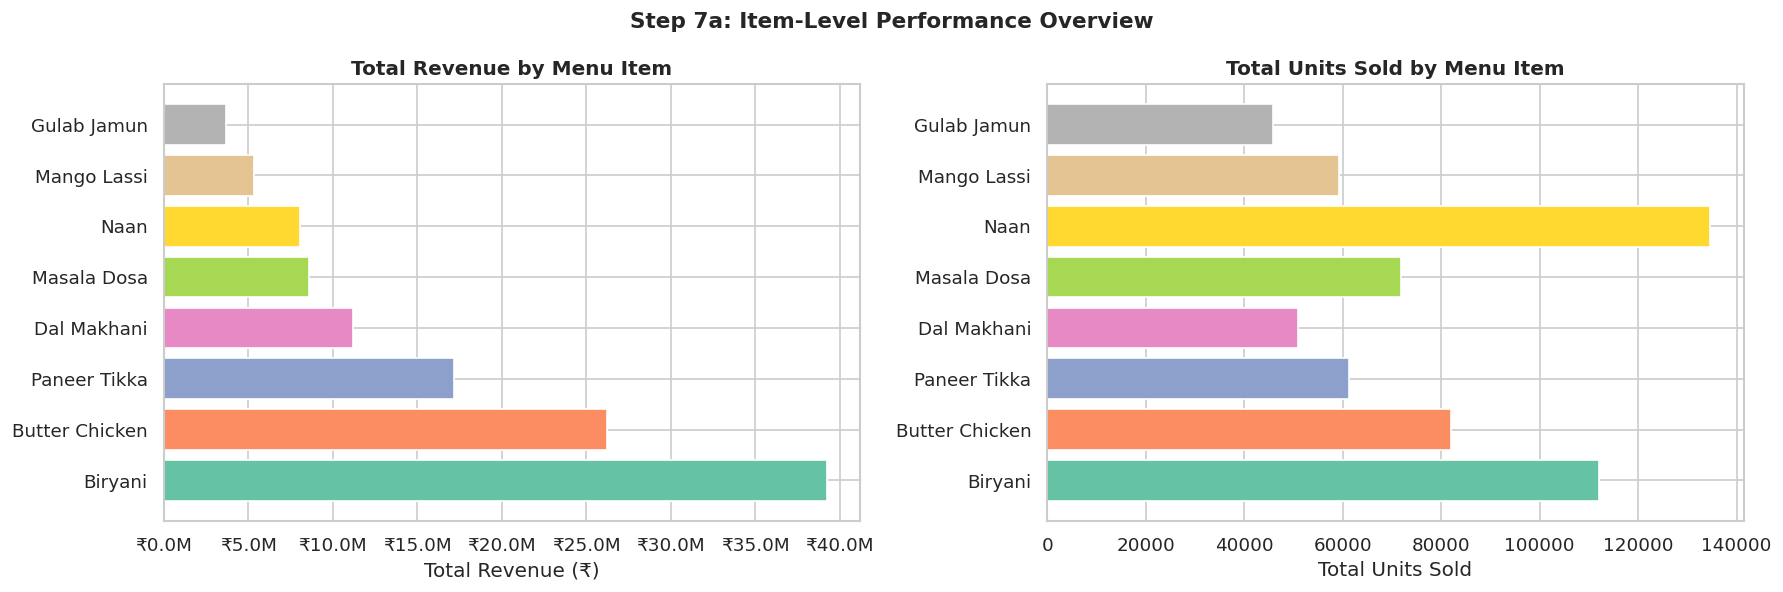

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Revenue share
axes[0].barh(item_summary.index, item_summary['total_revenue'],
             color=sns.color_palette('Set2', len(item_summary)))
axes[0].set_title('Total Revenue by Menu Item', fontweight='bold')
axes[0].set_xlabel('Total Revenue (₹)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

# Units sold
axes[1].barh(item_summary.index, item_summary['total_units'],
             color=sns.color_palette('Set2', len(item_summary)))
axes[1].set_title('Total Units Sold by Menu Item', fontweight='bold')
axes[1].set_xlabel('Total Units Sold')

plt.suptitle('Step 7a: Item-Level Performance Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 30-Day Rolling Trend per Item

Plotting a 30-day rolling average for each item reveals:  
- All items show an **upward trend** → consistent business growth
- **Naan** is the highest-volume item across the full period
- Seasonal spikes visible in Oct–Nov for all items (festive demand)
- **Mango Lassi** shows a subtle summer peak pattern

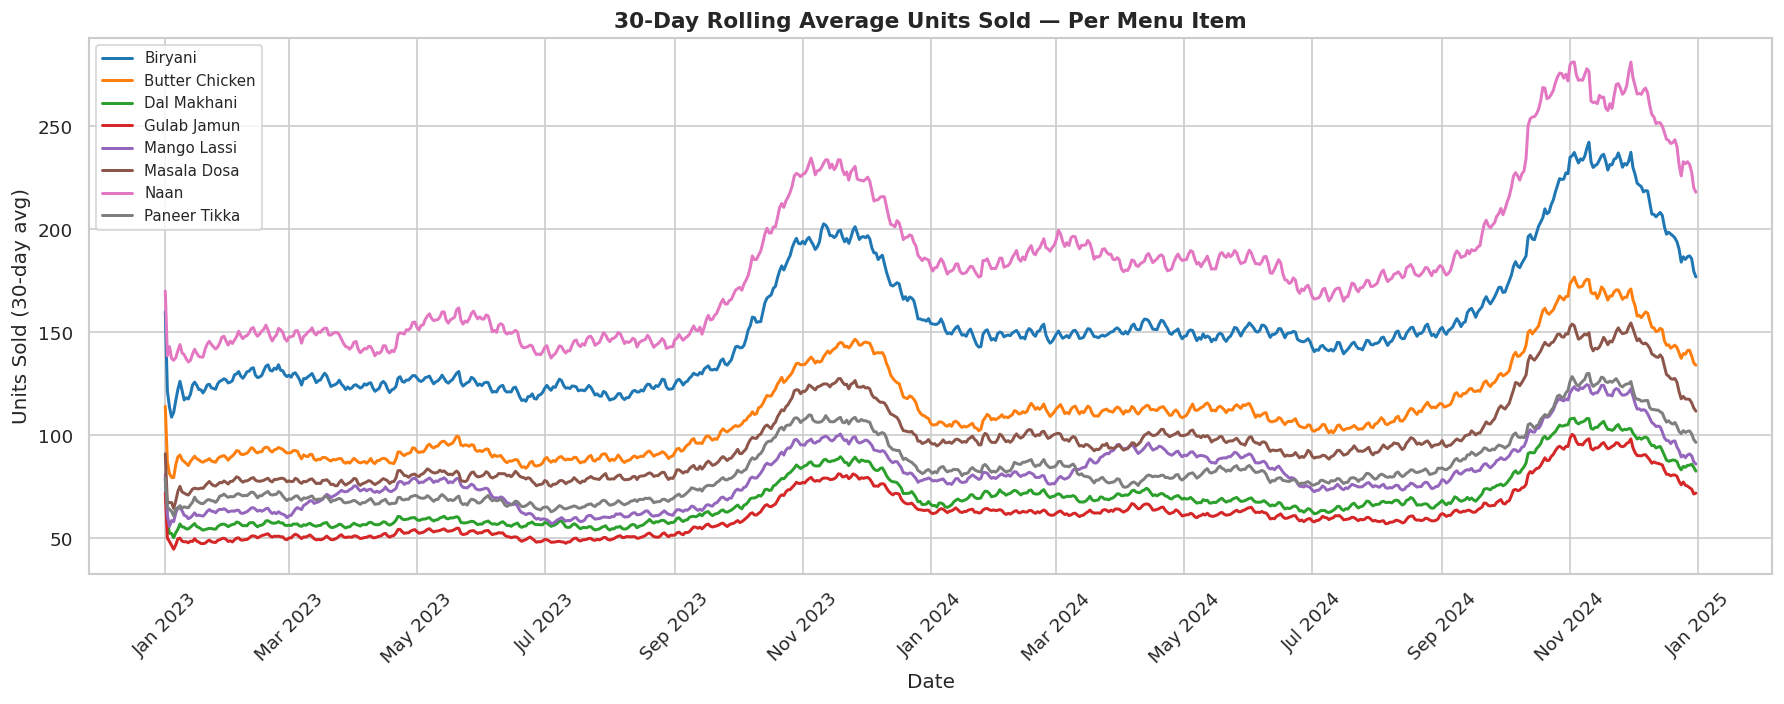


💡 Look for:
  - Items with rising lines → growing demand (good to stock more)
  - Items with falling lines → declining demand (reduce inventory)
  - Items with strong seasonal spikes → need seasonal forecasting



In [22]:
# ─── Daily trend per menu item ────────────────────────────────────────────────
# We plot the 30-day rolling average of units_sold for each item
# This shows whether each item is trending up, down, or flat

items = df['menu_item'].unique()
palette = sns.color_palette('tab10', len(items))

fig, ax = plt.subplots(figsize=(15, 6))

for item, color in zip(items, palette):
    item_daily = df[df['menu_item'] == item].groupby('date')['units_sold'].sum().reset_index()
    item_daily = item_daily.sort_values('date')
    item_daily['rolling_30d'] = item_daily['units_sold'].rolling(30, min_periods=1).mean()
    ax.plot(item_daily['date'], item_daily['rolling_30d'],
            label=item, color=color, linewidth=1.8)

ax.set_title('30-Day Rolling Average Units Sold — Per Menu Item', fontweight='bold', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Units Sold (30-day avg)')
ax.legend(loc='upper left', fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("""
💡 Look for:
  - Items with rising lines → growing demand (good to stock more)
  - Items with falling lines → declining demand (reduce inventory)
  - Items with strong seasonal spikes → need seasonal forecasting
""")

### Per-Item Weekly Demand Heatmap

This heatmap answers: **do all items peak on the same days?**  
If an item has a different weekly pattern, it may need its own lag/weekend features.

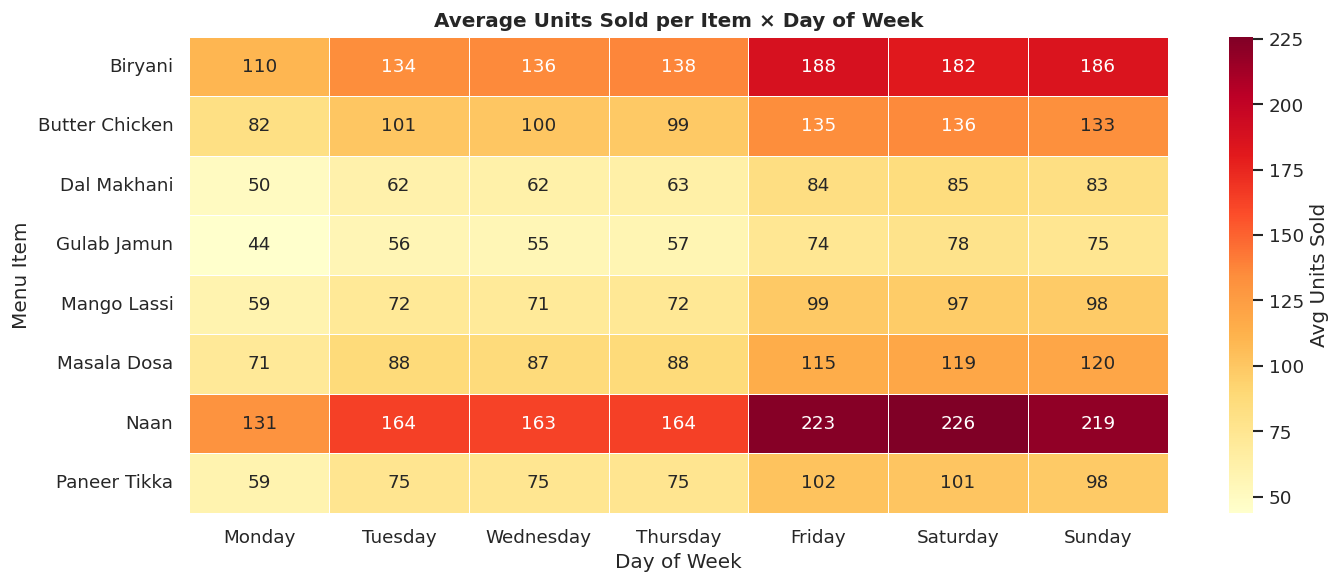

In [23]:
# ─── Weekly pattern per item ──────────────────────────────────────────────────
# Heatmap: menu_item × day_of_week → average units_sold
# Reveals if different items have different weekly demand curves

item_dow = df.groupby(['menu_item','day_of_week'])['units_sold'].mean().unstack()
item_dow = item_dow.reindex(columns=day_order)

plt.figure(figsize=(12, 5))
sns.heatmap(item_dow, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Avg Units Sold'})
plt.title('Average Units Sold per Item × Day of Week', fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Menu Item')
plt.tight_layout()
plt.show()

---
## Holiday vs Non-Holiday Impact

Our dataset has an `is_holiday` flag. Let's quantify how much holidays affect demand — this will be an important feature for our model.

## Holiday vs Non-Holiday Impact

The dataset includes an `is_holiday` flag for 7 Indian public holidays across both years.  
Quantifying the holiday premium tells us how valuable this feature will be for the model.

We also cross the holiday flag with the weekend flag to measure the **combined effect**:  
a holiday that falls on a weekend behaves differently from a mid-week holiday.

> High holiday premium → `is_holiday` will be one of the **top feature importance** entries in Week 3.

Average daily performance:
             total_revenue  total_units
Non-Holiday      161753.24       836.01
Holiday          256134.29      1334.57

Holiday premium: +58.3%


/tmp/ipykernel_5559/2925413198.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(groups, labels=['Non-Holiday','Holiday'], patch_artist=True)


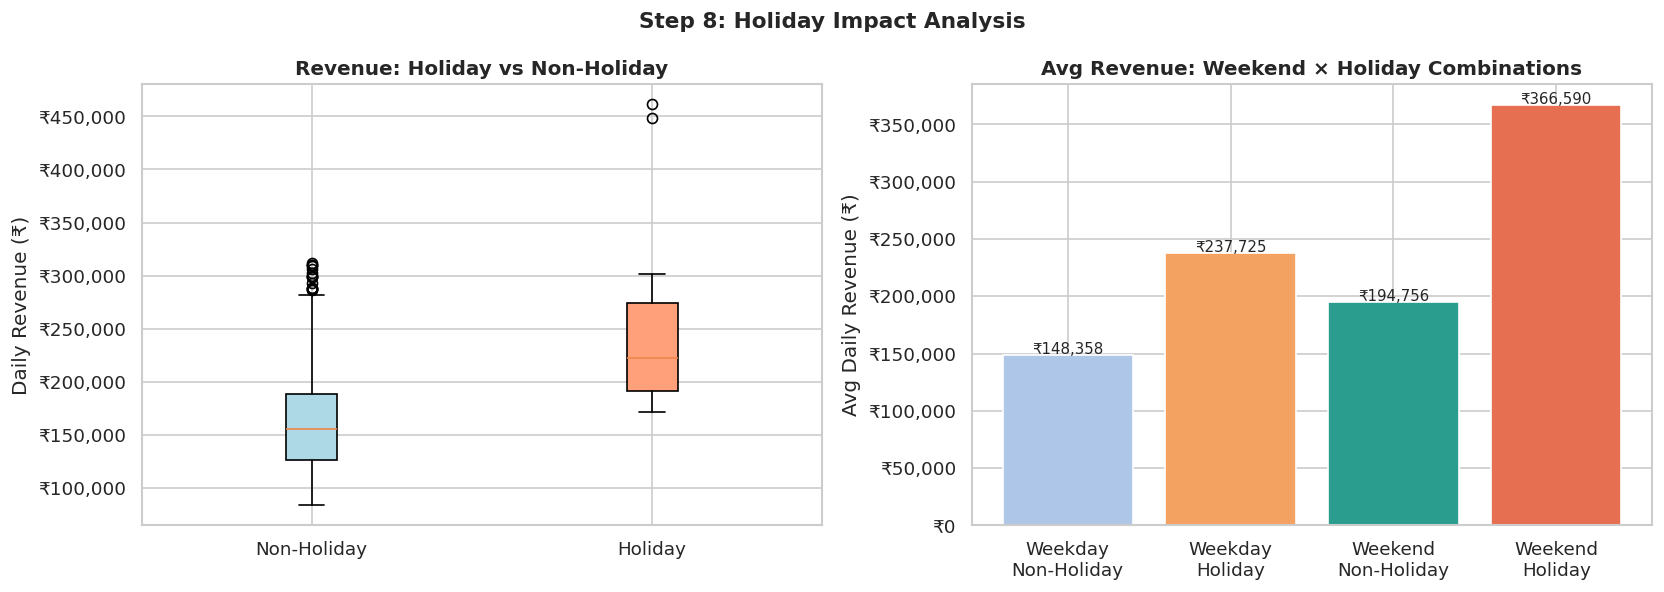

In [24]:
# ─── Holiday statistics ───────────────────────────────────────────────────────
holiday_stats = daily.groupby('is_holiday')[['total_revenue','total_units']].mean().round(2)
holiday_stats.index = ['Non-Holiday', 'Holiday']
print("Average daily performance:")
print(holiday_stats)

holiday_rev    = daily[daily['is_holiday']==1]['total_revenue'].mean()
nonholiday_rev = daily[daily['is_holiday']==0]['total_revenue'].mean()
print(f"\nHoliday premium: {((holiday_rev - nonholiday_rev)/nonholiday_rev)*100:+.1f}%")

# ─── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot: revenue on holiday vs non-holiday
groups = [daily[daily['is_holiday']==0]['total_revenue'],
          daily[daily['is_holiday']==1]['total_revenue']]
bp = axes[0].boxplot(groups, labels=['Non-Holiday','Holiday'], patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightsalmon')
axes[0].set_title('Revenue: Holiday vs Non-Holiday', fontweight='bold')
axes[0].set_ylabel('Daily Revenue (₹)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

# Bar chart: average by (weekend × holiday) combination
combo = daily.groupby(['is_weekend','is_holiday'])['total_revenue'].mean()
labels = ['Weekday\nNon-Holiday','Weekday\nHoliday','Weekend\nNon-Holiday','Weekend\nHoliday']
colors_combo = ['#aec6e8','#f4a261','#2a9d8f','#e76f51']
axes[1].bar(labels, combo.values, color=colors_combo, edgecolor='white')
axes[1].set_title('Avg Revenue: Weekend × Holiday Combinations', fontweight='bold')
axes[1].set_ylabel('Avg Daily Revenue (₹)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
for i, val in enumerate(combo.values):
    axes[1].text(i, val + 1000, f'₹{val:,.0f}', ha='center', fontsize=9)

plt.suptitle('Step 8: Holiday Impact Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Time-Series Decomposition

### What does decomposition do?
It mathematically **splits** the time series into 3 separate components:

| Component | What it means |
|-----------|---------------|
| **Trend** | Long-term growth or decline |
| **Seasonal** | Repeating periodic pattern (weekly / monthly) |
| **Residual** | Random noise — what's left after removing trend + seasonality |

We use `model='additive'` because: Total Revenue = Trend + Seasonal + Residual

## Time-Series Decomposition

### What does decomposition do?

It mathematically **splits** the time series into 3 components:

| Component | Formula | What it means |
|---|---|---|
| **Trend** | Long-run direction | Business is growing / shrinking |
| **Seasonal** | Repeating periodic pattern | Weekly or monthly cycles |
| **Residual** | Series − Trend − Seasonal | Unexplained random noise |

We use `model='additive'` because revenue = trend + seasonality + noise  
(as opposed to multiplicative, where seasonality scales with the trend level).

### Weekly Decomposition (period = 7)

Setting `period=7` extracts the **7-day repeating pattern** (Mon–Sun cycle).

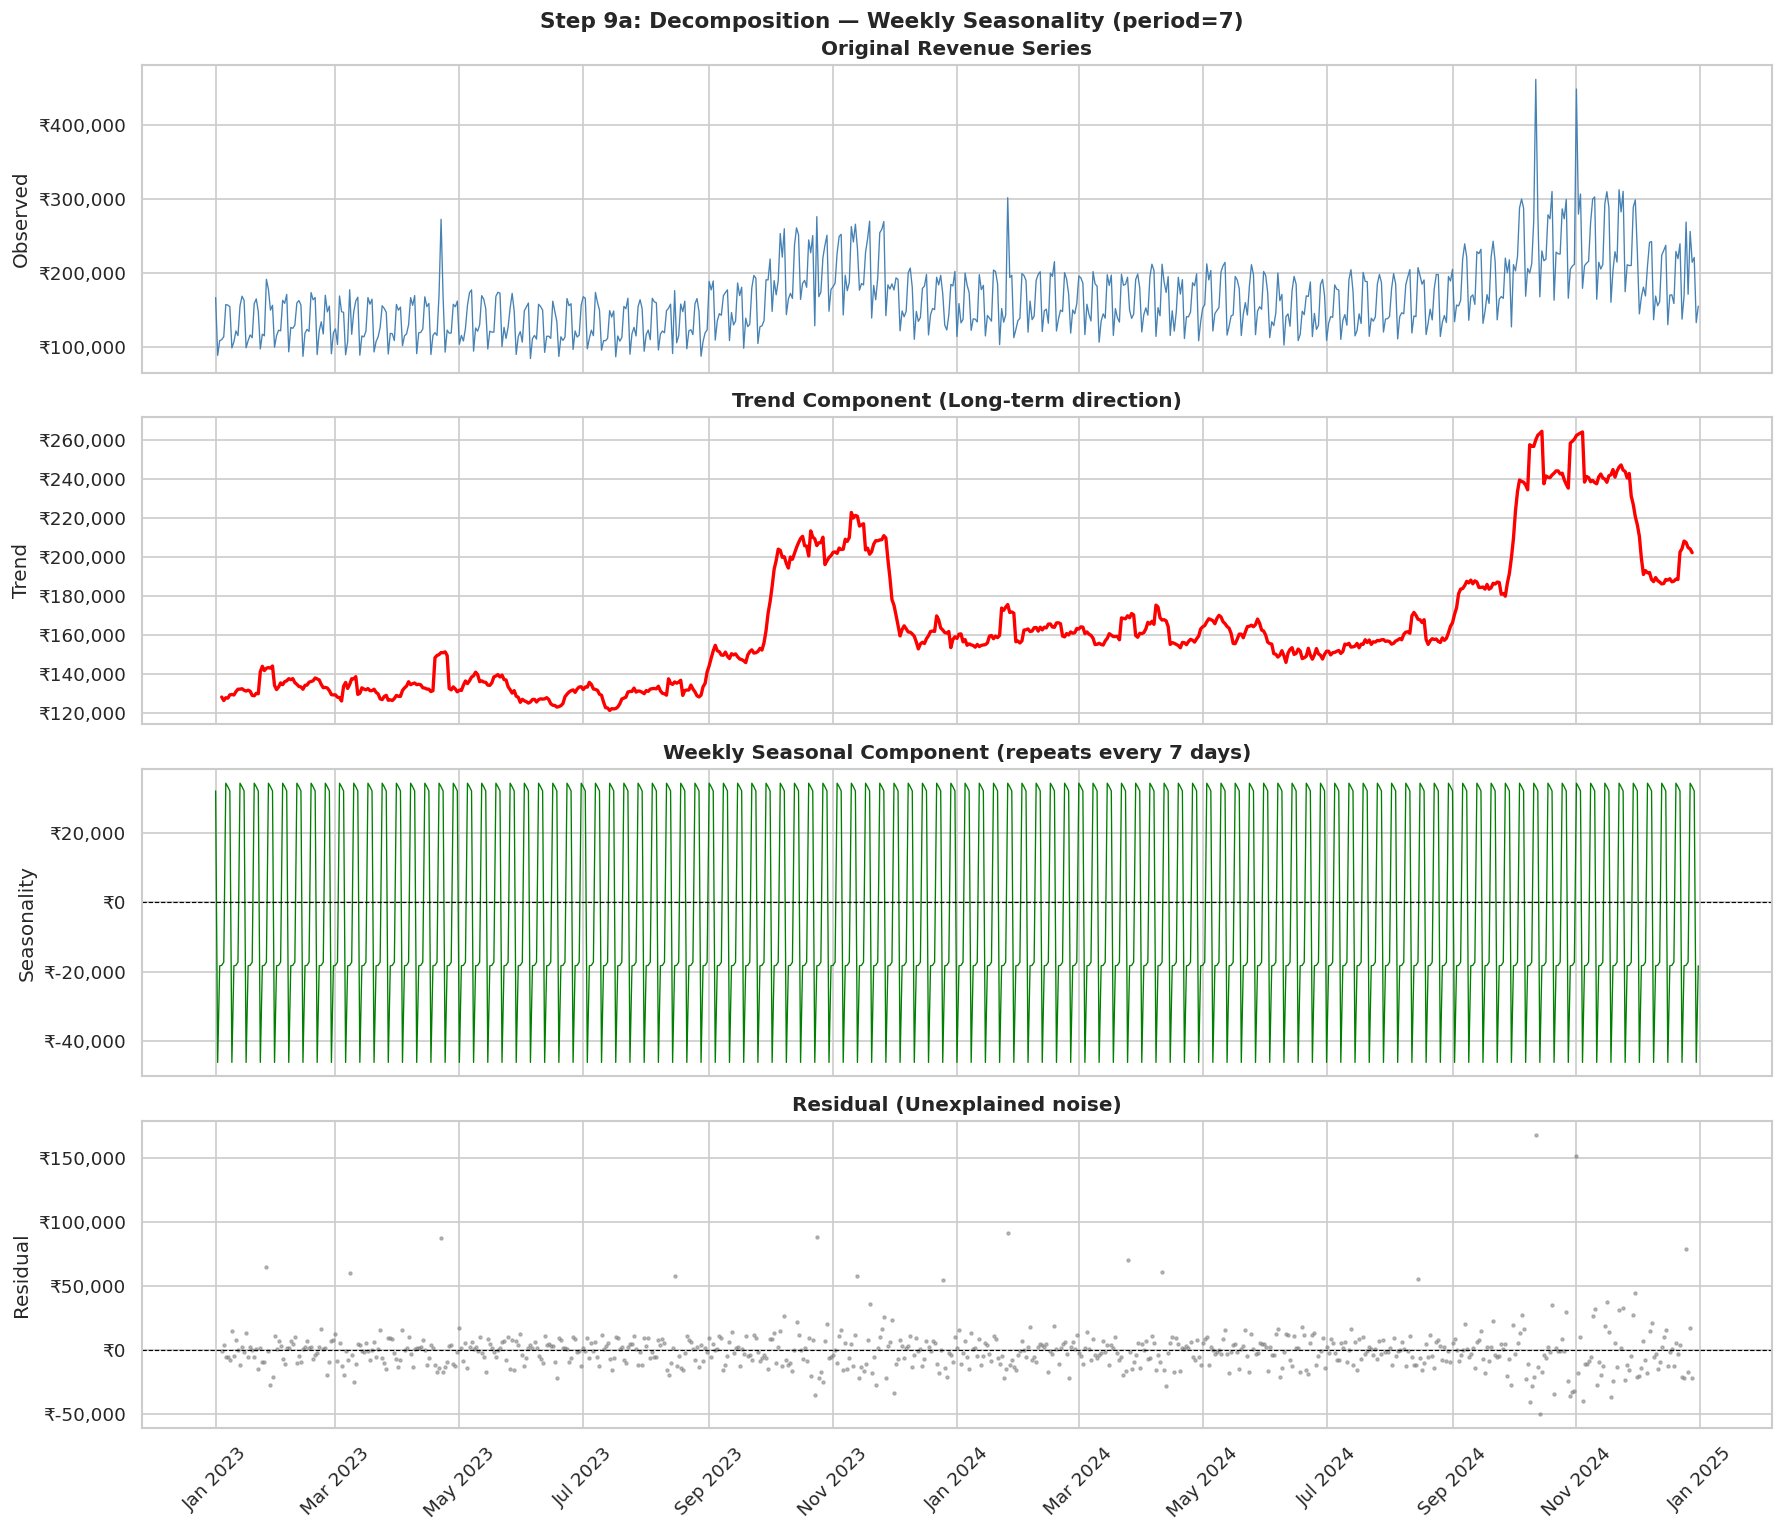


💡 Interpretation:
  - Trend: Does the red line slope upward? → Business is growing.
  - Seasonal: Regular oscillation = confirmed weekly pattern.
  - Residual: Should look random. Large isolated spikes = outlier days (festivals, events).



In [25]:
# ─── Set date as index for decomposition ─────────────────────────────────────
daily_ts = daily.set_index('date')['total_revenue']

# ─── Weekly decomposition (period=7) ─────────────────────────────────────────
decomp_weekly = seasonal_decompose(daily_ts, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)

axes[0].plot(daily_ts.index, decomp_weekly.observed,  color='steelblue', linewidth=0.8)
axes[0].set_ylabel('Observed'); axes[0].set_title('Original Revenue Series', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[1].plot(daily_ts.index, decomp_weekly.trend,     color='red',       linewidth=2)
axes[1].set_ylabel('Trend'); axes[1].set_title('Trend Component (Long-term direction)', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[2].plot(daily_ts.index, decomp_weekly.seasonal,  color='green',     linewidth=0.8)
axes[2].set_ylabel('Seasonality'); axes[2].set_title('Weekly Seasonal Component (repeats every 7 days)', fontweight='bold')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[3].scatter(daily_ts.index, decomp_weekly.resid, color='grey', s=3, alpha=0.5)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[3].set_ylabel('Residual'); axes[3].set_title('Residual (Unexplained noise)', fontweight='bold')
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('Step 9a: Decomposition — Weekly Seasonality (period=7)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
💡 Interpretation:
  - Trend: Does the red line slope upward? → Business is growing.
  - Seasonal: Regular oscillation = confirmed weekly pattern.
  - Residual: Should look random. Large isolated spikes = outlier days (festivals, events).
""")

### Monthly Decomposition (period = 30)

Setting `period=30` extracts the **30-day repeating cycle** — monthly seasonality.  
The seasonal panel here will show the festive-season October–November peaks clearly.

> **Interpretation tip:** If the residual panel has large isolated spikes, those are  
> likely holiday outlier days that the seasonal component cannot explain — they justify  
> the `is_holiday` feature.

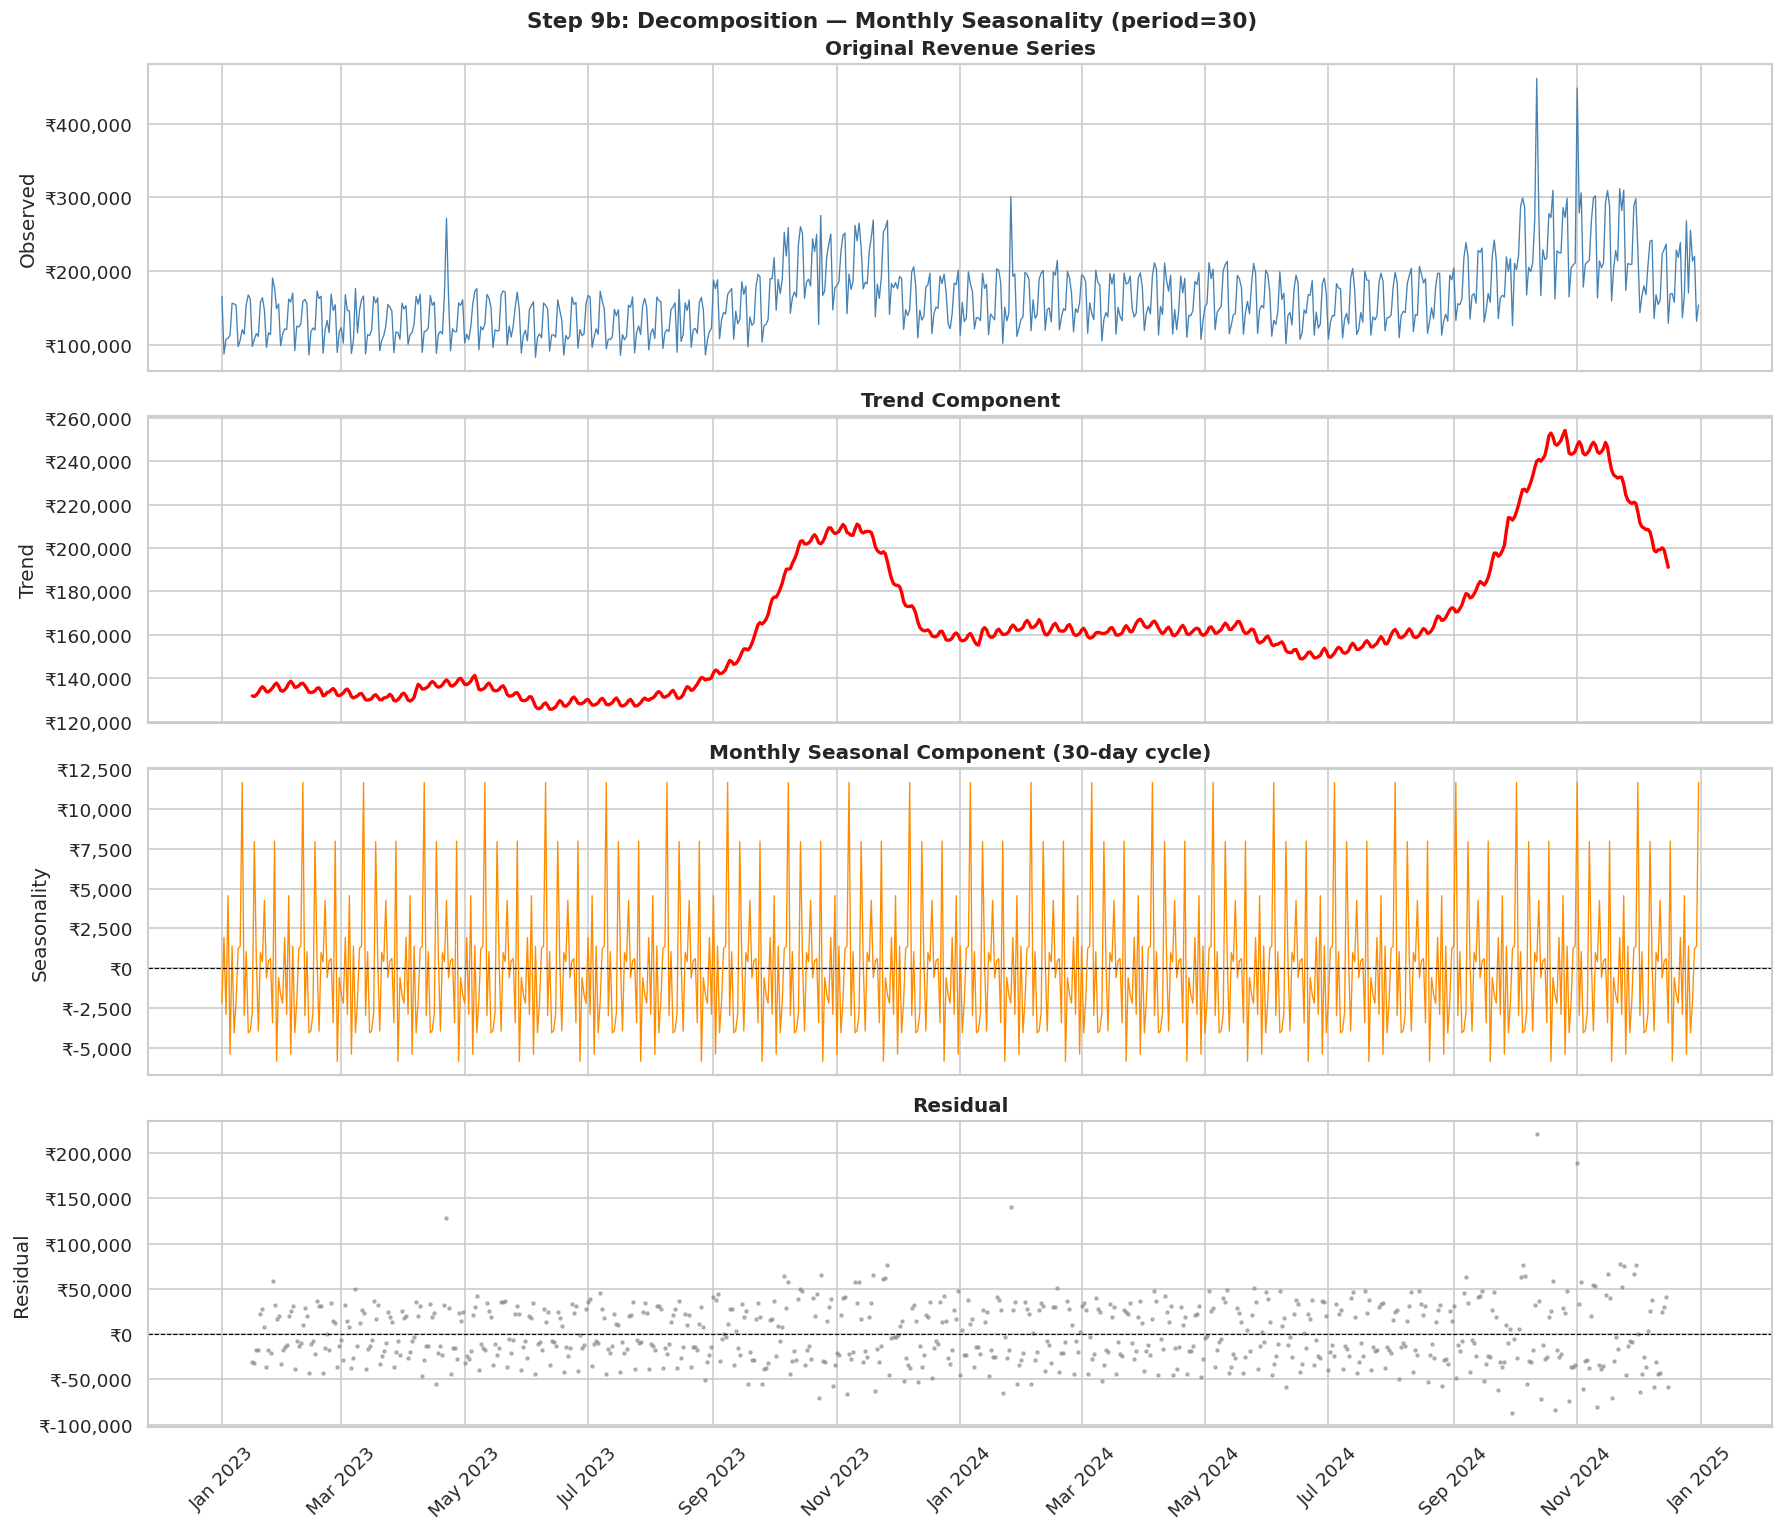

In [26]:
# ─── Monthly decomposition (period=30) ───────────────────────────────────────
decomp_monthly = seasonal_decompose(daily_ts, model='additive', period=30)

fig, axes = plt.subplots(4, 1, figsize=(15, 13), sharex=True)

axes[0].plot(daily_ts.index, decomp_monthly.observed,  color='steelblue',  linewidth=0.8)
axes[0].set_ylabel('Observed'); axes[0].set_title('Original Revenue Series', fontweight='bold')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[1].plot(daily_ts.index, decomp_monthly.trend,     color='red',        linewidth=2)
axes[1].set_ylabel('Trend'); axes[1].set_title('Trend Component', fontweight='bold')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[2].plot(daily_ts.index, decomp_monthly.seasonal,  color='darkorange',  linewidth=0.8)
axes[2].set_ylabel('Seasonality'); axes[2].set_title('Monthly Seasonal Component (30-day cycle)', fontweight='bold')
axes[2].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[3].scatter(daily_ts.index, decomp_monthly.resid, color='grey', s=3, alpha=0.5)
axes[3].axhline(0, color='black', linestyle='--', linewidth=0.7)
axes[3].set_ylabel('Residual'); axes[3].set_title('Residual', fontweight='bold')
axes[3].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))

axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[3].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45)

plt.suptitle('Step 9b: Decomposition — Monthly Seasonality (period=30)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Autocorrelation Analysis (ACF & PACF)

### What is Autocorrelation?
**ACF (Autocorrelation Function)** measures how strongly today's revenue is correlated with revenue from N days ago.

- **Lag 1** = correlation with yesterday's revenue
- **Lag 7** = correlation with same day last week
- Bars outside the **blue shaded band** are statistically significant

These patterns tell us **which lag features to include** in our ML model.

## 📊 Step 11: Autocorrelation Analysis (ACF & PACF)

### What is Autocorrelation?

**ACF (Autocorrelation Function)** measures how strongly today's revenue correlates  
with revenue from N days ago. Bars outside the **blue shaded confidence band** are statistically significant.

**PACF (Partial Autocorrelation Function)** measures the *direct* relationship at each lag,  
removing the indirect effect of shorter lags. This tells us which specific lags to use as features.

| Lag | Meaning | Expected finding |
|---|---|---|
| Lag 1 | Yesterday | Short-term momentum |
| Lag 7 | Same day last week | Weekly seasonality ✅ |
| Lag 14 | Two weeks ago | Fortnightly cycle ✅ |
| Lag 30 | One month ago | Monthly pattern |

> Spikes at multiples of 7 confirm weekly seasonality.  
> These lags become **lag features** in Week 2.

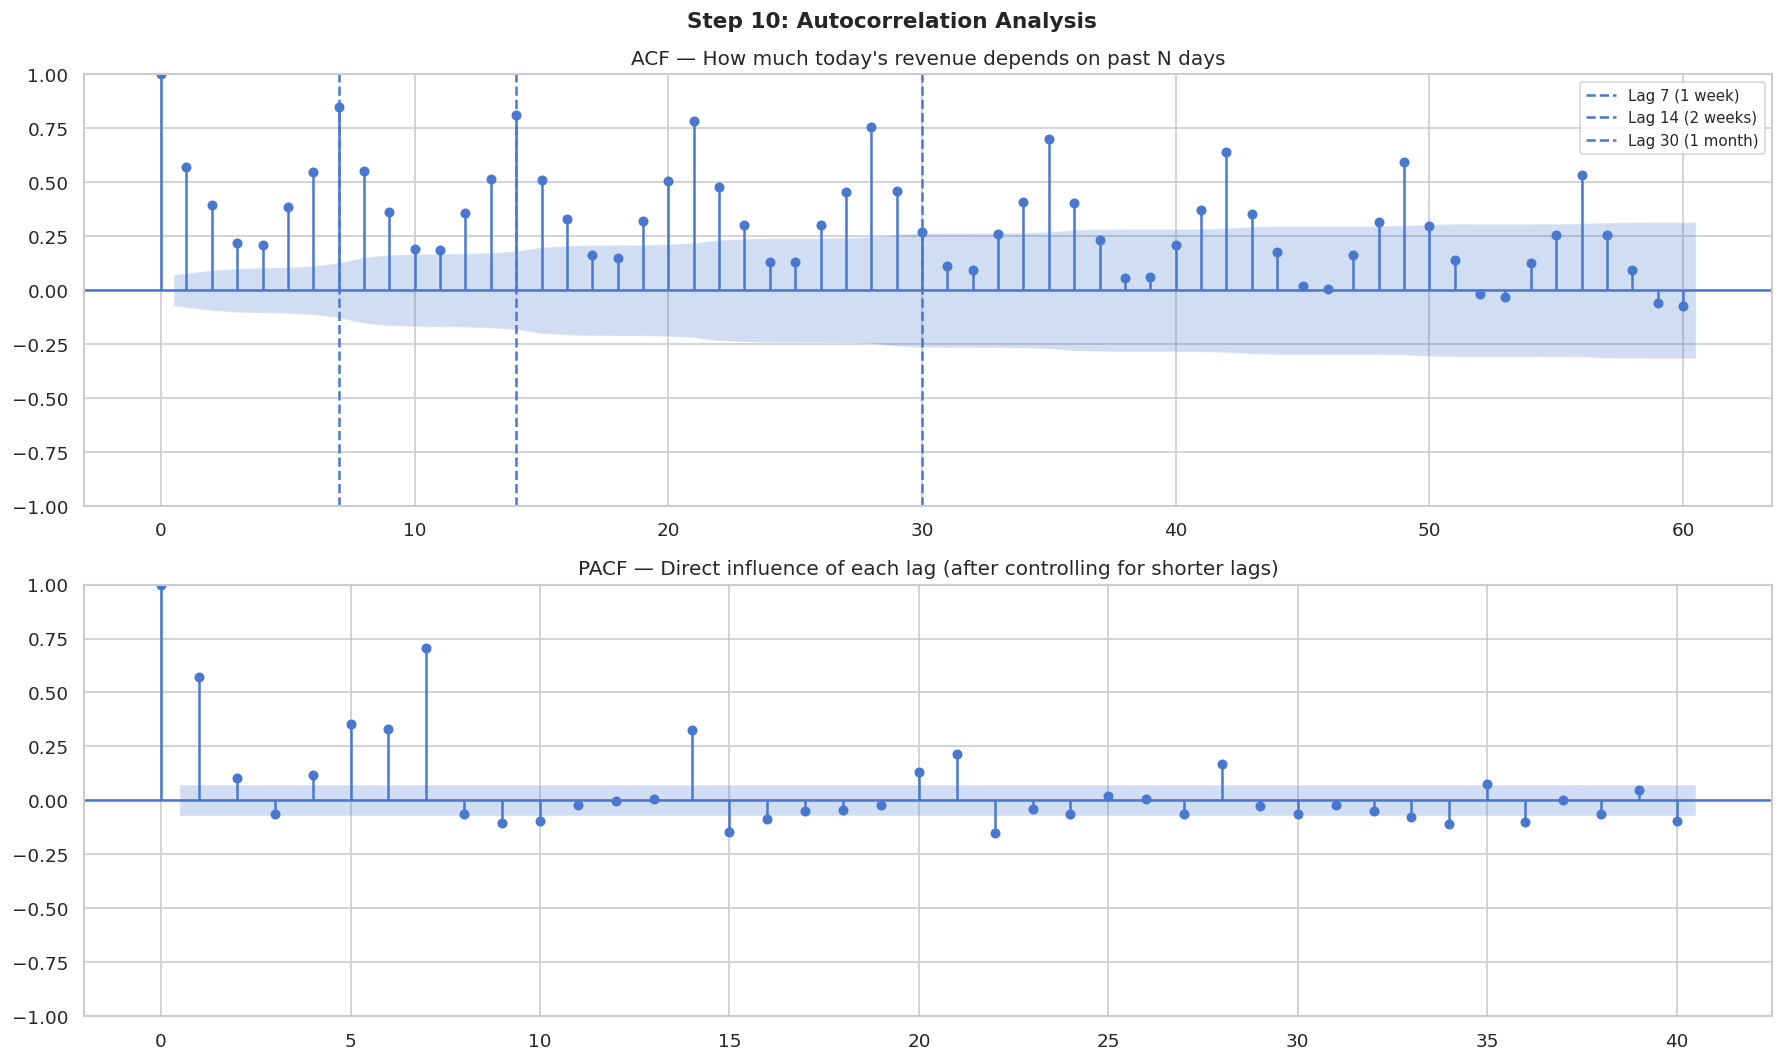

Key Autocorrelation Values:
  Lag  1: 0.5707  ✅ Significant
  Lag  2: 0.3962  ✅ Significant
  Lag  7: 0.8604  ✅ Significant
  Lag 14: 0.8286  ✅ Significant
  Lag 30: 0.2816  —


In [27]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9))

# ACF: total correlation at each lag
plot_acf(daily_ts.dropna(), lags=60, alpha=0.05, ax=axes[0],
         title="ACF — How much today's revenue depends on past N days")
axes[0].axvline(7,    linestyle='--', linewidth=1.5, label='Lag 7 (1 week)')
axes[0].axvline(14, linestyle='--', linewidth=1.5, label='Lag 14 (2 weeks)')
axes[0].axvline(30,  linestyle='--', linewidth=1.5, label='Lag 30 (1 month)')
axes[0].legend(fontsize=9)

# PACF: direct correlation at each lag (removing indirect effects)
plot_pacf(daily_ts.dropna(), lags=40, alpha=0.05, ax=axes[1],
          title='PACF — Direct influence of each lag (after controlling for shorter lags)')

plt.suptitle('Step 10: Autocorrelation Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Print key values ─────────────────────────────────────────────────────────
print("Key Autocorrelation Values:")
for lag in [1, 2, 7, 14, 30]:
    val = daily_ts.autocorr(lag=lag)
    print(f"  Lag {lag:>2}: {val:.4f}  {'✅ Significant' if abs(val) > 0.3 else '—'}")

---
## EDA Summary & Feature Engineering Plan

##EDA Summary & Feature Engineering Plan

This cell auto-generates the complete summary from the actual data —  
all numbers are computed live, not hardcoded.

The output maps every EDA finding directly to the feature it justifies,  
creating a clear evidence trail from analysis → model design.

In [28]:
# ─── Auto-generate summary from actual data ───────────────────────────────────
avg_2023 = daily[daily['year']==2023]['total_revenue'].mean()
avg_2024 = daily[daily['year']==2024]['total_revenue'].mean()
yoy_change = ((avg_2024 - avg_2023)/avg_2023)*100

best_day    = daily.groupby('day_of_week')['total_revenue'].mean().idxmax()
worst_day   = daily.groupby('day_of_week')['total_revenue'].mean().idxmin()
best_month  = daily.groupby('month_name')['total_revenue'].mean().idxmax()
worst_month = daily.groupby('month_name')['total_revenue'].mean().idxmin()
best_item   = df.groupby('menu_item')['revenue'].sum().idxmax()
wknd_prem   = ((daily[daily['is_weekend']==1]['total_revenue'].mean() /
                daily[daily['is_weekend']==0]['total_revenue'].mean()) - 1)*100
hol_prem    = ((daily[daily['is_holiday']==1]['total_revenue'].mean() /
                daily[daily['is_holiday']==0]['total_revenue'].mean()) - 1)*100

print("=" * 65)
print("       EDA SUMMARY — restaurant_sales.csv")
print("=" * 65)
print(f"""
1. DATASET
   ✅ 5,848 rows | 8 menu items | 731 dates (2023–2024)
   ✅ No missing dates, no null values

2. TREND
   📈 2023 daily avg: ₹{avg_2023:,.0f}
   📈 2024 daily avg: ₹{avg_2024:,.0f}
   📈 Year-on-year change: {yoy_change:+.1f}%
   → Include 'day_number' (integer index) as trend feature

3. WEEKLY SEASONALITY
   📅 Best day:  {best_day}
   📅 Worst day: {worst_day}
   📅 Weekend premium: +{wknd_prem:.1f}% over weekdays
   → Features: 'day_of_week', 'is_weekend'

4. MONTHLY SEASONALITY
   🗓️ Peak month:   {best_month}
   🗓️ Slowest month: {worst_month}
   → Feature: 'month'

5. HOLIDAY EFFECT
   🎉 Holiday premium: {hol_prem:+.1f}% over non-holidays
   → Feature: 'is_holiday' (already in dataset — valuable!)

6. TOP ITEM
   🍛 Highest revenue item: {best_item}
   → Train separate models per item, OR use 'menu_item' as a feature

7. AUTOCORRELATION
   🔁 Significant lags: 1, 7, 14
   🔁 Slowly decaying ACF → non-stationary series (has trend)
   → Lag features: lag_1, lag_7, lag_14
   → Rolling features: rolling_mean_7d, rolling_mean_30d

8. FEATURES TO ENGINEER FOR WEEK 2 MODEL
   ✅ day_of_week (0–6 or one-hot encoded)
   ✅ month (1–12)
   ✅ is_weekend (already in dataset)
   ✅ is_holiday (already in dataset)
   ✅ day_number (0, 1, 2, ... to capture trend)
   ✅ lag_1  = yesterday's total_revenue
   ✅ lag_7  = same day last week
   ✅ lag_14 = same day 2 weeks ago
   ✅ rolling_mean_7d  = 7-day rolling average
   ✅ rolling_mean_30d = 30-day rolling average
   ✅ menu_item (one-hot encoded for per-item forecasting)
""")
print("=" * 65)
print("   NEXT STEP: Week 1 Task 2 → Feature Engineering + Stationarity Tests")
print("=" * 65)

       EDA SUMMARY — restaurant_sales.csv

1. DATASET
   ✅ 5,848 rows | 8 menu items | 731 dates (2023–2024)
   ✅ No missing dates, no null values

2. TREND
   📈 2023 daily avg: ₹148,654
   📈 2024 daily avg: ₹178,426
   📈 Year-on-year change: +20.0%
   → Include 'day_number' (integer index) as trend feature

3. WEEKLY SEASONALITY
   📅 Best day:  Friday
   📅 Worst day: Monday
   📅 Weekend premium: +30.6% over weekdays
   → Features: 'day_of_week', 'is_weekend'

4. MONTHLY SEASONALITY
   🗓️ Peak month:   November
   🗓️ Slowest month: June
   → Feature: 'month'

5. HOLIDAY EFFECT
   🎉 Holiday premium: +58.3% over non-holidays
   → Feature: 'is_holiday' (already in dataset — valuable!)

6. TOP ITEM
   🍛 Highest revenue item: Biryani
   → Train separate models per item, OR use 'menu_item' as a feature

7. AUTOCORRELATION
   🔁 Significant lags: 1, 7, 14
   🔁 Slowly decaying ACF → non-stationary series (has trend)
   → Lag features: lag_1, lag_7, lag_14
   → Rolling features: rolling_mean_7d,

## 🔍 Autocorrelation Analysis

Autocorrelation analysis is used to understand how past values in a time series influence future values. It helps in identifying repeating patterns and temporal dependencies in the data.

The Autocorrelation Function (ACF) measures the correlation between the time series and its past values over different lags. It is useful for identifying overall patterns such as trend and seasonality.

The Partial Autocorrelation Function (PACF) measures the direct relationship between the time series and its lagged values by removing the effect of intermediate lags. It helps in identifying the most relevant lag features for modeling.

### 📊 Interpretation

The ACF plot shows how the current sales values are correlated with past values over different time lags.

A significant spike at lag 7 indicates the presence of weekly seasonality in the data, suggesting that sales patterns tend to repeat every week. This is commonly observed in retail and restaurant datasets due to consistent customer behavior.

A noticeable spike at lag 1 indicates short-term dependency, meaning that recent sales influence immediate future sales.

The gradual decline observed in the ACF plot suggests the presence of a trend component in the time series.

The PACF plot highlights the most significant lags that directly influence future values. Strong spikes at lag 1 and lag 7 indicate that these are important predictors for forecasting.

These observations will be useful for creating lag features in the next stage of the project.



### ✅ Conclusion

The autocorrelation analysis reveals that the time series exhibits both short-term and seasonal dependencies. Weekly patterns and immediate past influences are clearly observed.

These findings will guide feature engineering by selecting relevant lag values such as lag-1 and lag-7 to improve model performance.

---

# 🗓️ Week 2: Feature Engineering

EDA told us *what* patterns exist. Feature engineering *encodes* those patterns  
into numerical columns that a machine learning model can learn from.

## Task 1: Chronological Features

**Chronological features** extract time-based signals directly from the `date` column.

| Feature | Type | What it captures |
|---|---|---|
| `day_of_week` | 0–6 integer | Which day of the week (weekly seasonality) |
| `day_name` | string label | Human-readable day name |
| `month` | 1–12 integer | Which month (monthly seasonality) |
| `month_name` | string label | Human-readable month name |
| `year` | integer | Year (long-term trend) |
| `quarter` | 1–4 integer | Business quarter |
| `week_of_year` | 1–52 integer | ISO week number |
| `is_weekend` | 0/1 binary | Weekend flag (already in dataset) |
| `is_holiday` | 0/1 binary | Holiday flag (already in dataset) |

In [29]:
# ============================================================
# Step 1: Check daily dataset from Task 1
# ============================================================

print("Daily dataset shape:", daily.shape)

print("\nFirst 5 rows:")
print(daily.head())

Daily dataset shape: (731, 13)

First 5 rows:
        date  total_revenue  total_units  is_weekend  is_holiday day_of_week  \
0 2023-01-01         166150          846           1           0      Sunday   
1 2023-01-02          88180          450           0           0      Monday   
2 2023-01-03         108010          581           0           0     Tuesday   
3 2023-01-04         109370          575           0           0   Wednesday   
4 2023-01-05         113420          572           0           0    Thursday   

   month  year month_name  quarter  week  rolling_7d  rolling_30d  
0      1  2023    January        1    52    166150.0     166150.0  
1      1  2023    January        1     1    127165.0     127165.0  
2      1  2023    January        1     1    120780.0     120780.0  
3      1  2023    January        1     1    117927.5     117927.5  
4      1  2023    January        1     1    117026.0     117026.0  


In [30]:
# ------------------------------------------------------------
# 📌 Step 2: Create Chronological Features
# ------------------------------------------------------------

# Day of week (Monday=0, Sunday=6)
daily['day_of_week'] = daily['date'].dt.dayofweek

# Day name (Monday, Tuesday...)
daily['day_name'] = daily['date'].dt.day_name()

# Month number
daily['month'] = daily['date'].dt.month

# Month name
daily['month_name'] = daily['date'].dt.month_name()

# Year
daily['year'] = daily['date'].dt.year

# Quarter
daily['quarter'] = daily['date'].dt.quarter

# Week of year
daily['week_of_year'] = daily['date'].dt.isocalendar().week.astype(int)


In [31]:
# ------------------------------------------------------------
# 📌 Step 3: Ensure Weekend and Holiday columns are numeric
# ------------------------------------------------------------
daily['is_weekend'] = daily['is_weekend'].astype(int)
daily['is_holiday'] = daily['is_holiday'].astype(int)


In [32]:
# ------------------------------------------------------------
# 📌 Step 4: Preview Updated Dataset
# ------------------------------------------------------------
print("\nUpdated dataset shape:", daily.shape)

print("\nColumns after feature engineering:")
print(daily.columns.tolist())

print("\nFirst 10 rows:")
print(daily.head(10))


Updated dataset shape: (731, 15)

Columns after feature engineering:
['date', 'total_revenue', 'total_units', 'is_weekend', 'is_holiday', 'day_of_week', 'month', 'year', 'month_name', 'quarter', 'week', 'rolling_7d', 'rolling_30d', 'day_name', 'week_of_year']

First 10 rows:
        date  total_revenue  total_units  is_weekend  is_holiday  day_of_week  \
0 2023-01-01         166150          846           1           0            6   
1 2023-01-02          88180          450           0           0            0   
2 2023-01-03         108010          581           0           0            1   
3 2023-01-04         109370          575           0           0            2   
4 2023-01-05         113420          572           0           0            3   
5 2023-01-06         156790          780           0           0            4   
6 2023-01-07         156060          805           1           0            5   
7 2023-01-08         153770          775           1           0           

In [33]:
# ------------------------------------------------------------
# 📌 Step 5: Final Feature Set for Forecasting
# ------------------------------------------------------------
X = daily[['day_of_week', 'month', 'quarter',
           'week_of_year', 'is_weekend', 'is_holiday']]

y = daily['total_revenue']

print("\nFeature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nSample Features:")
print(X.head())


Feature Matrix Shape: (731, 6)
Target Shape: (731,)

Sample Features:
   day_of_week  month  quarter  week_of_year  is_weekend  is_holiday
0            6      1        1            52           1           0
1            0      1        1             1           0           0
2            1      1        1             1           0           0
3            2      1        1             1           0           0
4            3      1        1             1           0           0


In [34]:
# ------------------------------------------------------------
# 📌 Step 6: Conclusion
# ------------------------------------------------------------
print("="*50)
print("CHRONOLOGICAL FEATURE ENGINEERING")
print("="*50)

print("""
Created Features:
✔ day_of_week
✔ day_name
✔ month
✔ month_name
✔ year
✔ quarter
✔ week_of_year
✔ is_weekend
✔ is_holiday

🔍 These features help the model understand:
• Weekly sales patterns
• Monthly trends
• Weekend demand
• Holiday spikes
""")

CHRONOLOGICAL FEATURE ENGINEERING

Created Features:
✔ day_of_week
✔ day_name
✔ month
✔ month_name
✔ year
✔ quarter
✔ week_of_year
✔ is_weekend
✔ is_holiday

🔍 These features help the model understand:
• Weekly sales patterns
• Monthly trends
• Weekend demand
• Holiday spikes



###🔍 Interpretation

These features help us understand when sales are usually high or low.

Higher weekend sales = weekend demand

Holiday spikes = special event demand

Monthly changes = seasonal trends

###🔍 Conclusion

Chronological features help the model learn calendar-based sales behavior.

✔ Day of week → Weekly pattern

✔ Month → Seasonal trend

✔ Weekend → Busy days

✔ Holiday → Special sales spikes

These features improve forecasting by helping the model understand how time affects restaurant demand.

---

## Task 2: Lag Features, Rolling Window Statistics & Sequential Data Split

This is the most critical feature engineering step for time-series forecasting.

### Why lag features?

A standard ML model sees each row as **independent** — it has no memory.  
Lag features give the model **memory** by explicitly passing it past sales values.

| Feature | Source | Captures |
|---|---|---|
| `lag_1` | Revenue 1 day ago | Short-term momentum |
| `lag_7` | Revenue 7 days ago | Same day last week — strongest feature |
| `lag_14` | Revenue 14 days ago | Two-week cycle |

### Why rolling window statistics?

Rolling averages smooth out daily noise and capture **local trend direction**:  
Is demand currently rising, falling, or stable?

| Feature | Window | Captures |
|---|---|---|
| `rolling_7_mean` | 7 days | Recent weekly demand level |
| `rolling_14_mean` | 14 days | Fortnightly trend |
| `rolling_30_mean` | 30 days | Monthly demand momentum |

### Why sequential split?

Standard random train-test split would cause **data leakage** — the model would  
see future data during training. For time series, we always split chronologically:
- **Train:** first 10 months
- **Test:** last 2 months

> This simulates real-world forecasting: the model only ever sees the past.

In [35]:
# ============================================================
# TASK 4: LAG FEATURES + ROLLING FEATURES + TIME SPLIT
# ============================================================

# Step 1: Check current daily dataset
print("Current dataset shape:", daily.shape)

Current dataset shape: (731, 15)


In [36]:
# ------------------------------------------------------------
# Step 2: Create Lag Features
# These use previous sales values
# ------------------------------------------------------------

# 1 day ago
daily['lag_1'] = daily['total_revenue'].shift(1)

# 7 days ago
daily['lag_7'] = daily['total_revenue'].shift(7)

# 14 days ago
daily['lag_14'] = daily['total_revenue'].shift(14)

In [37]:
# ------------------------------------------------------------
# Step 3: Create Rolling Window Features
# These capture moving trends
# ------------------------------------------------------------

# 7-day moving average
daily['rolling_7_mean'] = daily['total_revenue'].rolling(window=7).mean()

# 14-day moving average
daily['rolling_14_mean'] = daily['total_revenue'].rolling(window=14).mean()

# 30-day moving average
daily['rolling_30_mean'] = daily['total_revenue'].rolling(window=30).mean()


In [38]:
# ------------------------------------------------------------
# Step 4: Remove rows with NaN values
# First rows will be empty because lag/rolling need past data
# ------------------------------------------------------------
daily_model = daily.dropna().reset_index(drop=True)

print("\nDataset shape after lag + rolling features:", daily_model.shape)


Dataset shape after lag + rolling features: (702, 21)


In [39]:
# ------------------------------------------------------------
# Step 5: Check new columns
# ------------------------------------------------------------
print("\nUpdated columns:")
print(daily_model.columns.tolist())

print("\nFirst 10 rows:")
print(daily_model.head(10))


Updated columns:
['date', 'total_revenue', 'total_units', 'is_weekend', 'is_holiday', 'day_of_week', 'month', 'year', 'month_name', 'quarter', 'week', 'rolling_7d', 'rolling_30d', 'day_name', 'week_of_year', 'lag_1', 'lag_7', 'lag_14', 'rolling_7_mean', 'rolling_14_mean', 'rolling_30_mean']

First 10 rows:
        date  total_revenue  total_units  is_weekend  is_holiday  day_of_week  \
0 2023-01-30          99240          477           0           0            0   
1 2023-01-31         114820          572           0           0            1   
2 2023-02-01         122050          648           0           0            2   
3 2023-02-02         121230          587           0           0            3   
4 2023-02-03         162530          814           0           0            4   
5 2023-02-04         158450          818           1           0            5   
6 2023-02-05         170490          876           1           0            6   
7 2023-02-06          92900          476   

In [40]:
# ------------------------------------------------------------
# Step 6: Sequential Train-Test Split
#
# ------------------------------------------------------------

# Make sure data is sorted chronologically
daily_model = daily_model.sort_values('date').reset_index(drop=True)

# 80/20 split on row count
total_rows = len(daily_model)
train_size = int(total_rows * 0.80)

train = daily_model.iloc[:train_size]
test  = daily_model.iloc[train_size:]

print(f'Total rows available : {total_rows}')
print(f'Train size (80%)     : {len(train)} rows')
print(f'Test  size (20%)     : {len(test)}  rows')
print(f'Train period: {train["date"].min().date()} → {train["date"].max().date()}')
print(f'Test  period: {test["date"].min().date()}  → {test["date"].max().date()}')
print(f'\nTrain %: {len(train)/total_rows*100:.1f}%  |  Test %: {len(test)/total_rows*100:.1f}%')


Total rows available : 702
Train size (80%)     : 561 rows
Test  size (20%)     : 141  rows
Train period: 2023-01-30 → 2024-08-12
Test  period: 2024-08-13  → 2024-12-31

Train %: 79.9%  |  Test %: 20.1%


In [41]:
# ------------------------------------------------------------
# Step 7: Final Features for Modeling
# ------------------------------------------------------------
feature_cols = [
    'day_of_week',
    'month',
    'quarter',
    'week_of_year',
    'is_weekend',
    'is_holiday',
    'lag_1',
    'lag_7',
    'lag_14',
    'rolling_7_mean',
    'rolling_14_mean',
    'rolling_30_mean'
]

X_train = train[feature_cols]
y_train = train['total_revenue']

X_test = test[feature_cols]
y_test = test['total_revenue']

print("\nX_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nSample Training Features:")
print(X_train.head())



X_train shape: (561, 12)
X_test shape: (141, 12)

Sample Training Features:
   day_of_week  month  quarter  week_of_year  is_weekend  is_holiday  \
0            0      1        1             5           0           0   
1            1      1        1             5           0           0   
2            2      2        1             5           0           0   
3            3      2        1             5           0           0   
4            4      2        1             5           0           0   

      lag_1     lag_7    lag_14  rolling_7_mean  rolling_14_mean  \
0  155790.0   96850.0   98350.0   143390.000000    136158.571429   
1   99240.0  116780.0  108020.0   143110.000000    136644.285714   
2  114820.0  114470.0  115740.0   144192.857143    137095.000000   
3  122050.0  190960.0  111960.0   134231.428571    137757.142857   
4  121230.0  177290.0  157970.0   132122.857143    138082.857143   

   rolling_30_mean  
0    132748.333333  
1    131037.333333  
2    132166.333333

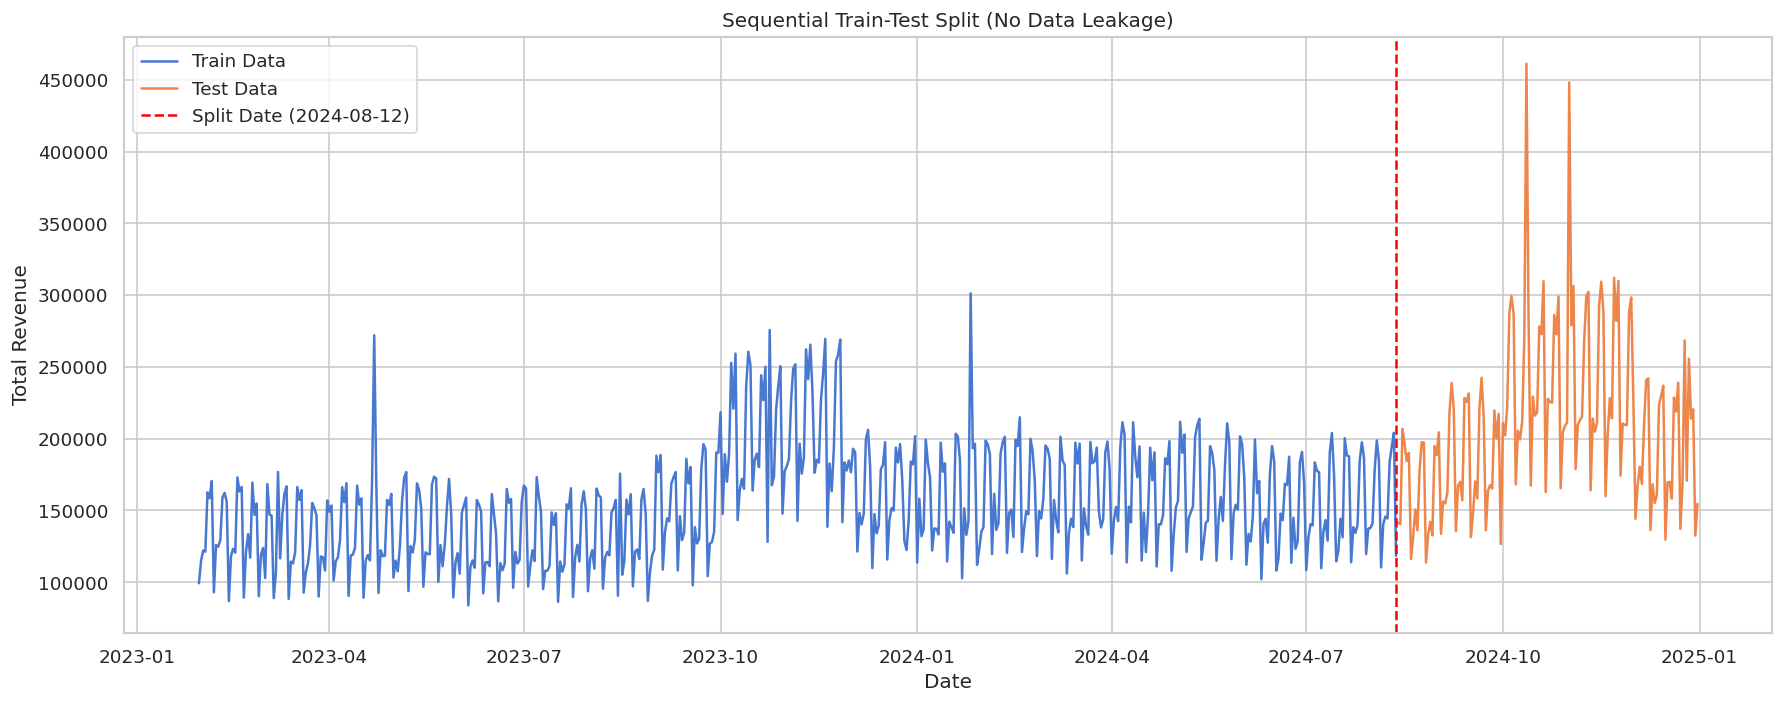

In [44]:
# ------------------------------------------------------------
# Step 8: Visualize Train-Test Split
# ------------------------------------------------------------
import matplotlib.pyplot as plt

# The split boundary is the last date of training data
split_boundary = train['date'].max()

plt.figure(figsize=(15, 6))
plt.plot(train['date'], train['total_revenue'], label='Train Data')
plt.plot(test['date'],  test['total_revenue'],  label='Test Data')
plt.axvline(split_boundary, color='red', linestyle='--', label=f'Split Date ({split_boundary.date()})')
plt.title('Sequential Train-Test Split (No Data Leakage)')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.legend()
plt.tight_layout()
plt.show()

In [45]:
# ------------------------------------------------------------
# Step 9: Task 4 Conclusion
# ------------------------------------------------------------
print("="*60)
print("LAG FEATURES + ROLLING WINDOWS")
print("="*60)

print("""
Created Features:
✔ lag_1           → Yesterday's sales
✔ lag_7           → Sales from last week
✔ lag_14          → Sales from 2 weeks ago
✔ rolling_7_mean  → 7-day moving average
✔ rolling_14_mean → 14-day moving average
✔ rolling_30_mean → 30-day moving average

🔍 Why this matters:
These features help the model learn:
• Short-term demand
• Weekly seasonality
• Trend direction
• Sales momentum

""")

LAG FEATURES + ROLLING WINDOWS

Created Features:
✔ lag_1           → Yesterday's sales
✔ lag_7           → Sales from last week
✔ lag_14          → Sales from 2 weeks ago
✔ rolling_7_mean  → 7-day moving average
✔ rolling_14_mean → 14-day moving average
✔ rolling_30_mean → 30-day moving average

🔍 Why this matters:
These features help the model learn:
• Short-term demand
• Weekly seasonality
• Trend direction
• Sales momentum


